# Uncertainty Estimation

# Setup

In [1]:
import os
import json

import corner
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import tensorflow as tf
from tqdm import tqdm

from geexhp import datavis

datavis.configure_matplotlib()

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

2026-03-24 12:27:31.749722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774366051.770494   62954 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774366051.777291   62954 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774366051.794770   62954 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774366051.794802   62954 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774366051.794804   62954 computation_placer.cc:177] computation placer alr

In [2]:
B_BOOTSTRAP = 5000  # noise realizations for data uncertainty
N_MC = 50  # MC-Dropout passes for model uncertainty
SNR_SCALES = [0.5, 1.0, 2.0, 4.0]  # noise scale factors (1.0 = default)
BATCH_SIZE = 512
SEED = 42

TELESCOPE_CONFIG = {
    "LUVOIR": {"prefix": "B", "bins": {"UV": 8, "Vis": 94, "NIR": 49}},
    "HABEX": {"prefix": "SS", "bins": {"UV": 7, "Vis": 109, "NIR": 25}},
}

PHYS_PARAMS = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
]

MAIN_CHEM = ["O2", "O3"]
OTHER_CHEM = ["CH4", "CO2", "H2O", "N2"]
ALL_PARAMS = PHYS_PARAMS + MAIN_CHEM + OTHER_CHEM

PARAM_LABELS = [
    r"R$_\oplus$",
    r"$g$",
    r"$T_{\text{surf}}$",
    r"$P_{\text{surf}}$",
    r"O$_2$",
    r"O$_3$",
    r"CH$_4$",
    r"CO$_2$",
    r"H$_2$O",
    r"N$_2$",
]

N_PARAMS = len(PARAM_LABELS)

# Load Models and Normalization Statistics

In [3]:
with open("../data/normalization_stats.json") as f:
    norm_stats = json.load(f)

model_LUVOIR = tf.keras.models.load_model("../models/luvoir_model.keras")
print("LUVOIR loaded.")
model_HABEX = tf.keras.models.load_model("../models/habex_model.keras")
print("HABEX loaded.")

print("Models loaded.")
print("  LUVOIR inputs:", [inp.name for inp in model_LUVOIR.inputs])
print("  HABEX  inputs:", [inp.name for inp in model_HABEX.inputs])

I0000 00:00:1774366054.572122   62954 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4070 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:08:00.0, compute capability: 7.5


LUVOIR loaded.
HABEX loaded.
Models loaded.
  LUVOIR inputs: ['NOISY_ALBEDO_B-UV', 'NOISY_ALBEDO_B-Vis', 'NOISY_ALBEDO_B-NIR']
  HABEX  inputs: ['NOISY_ALBEDO_SS-UV', 'NOISY_ALBEDO_SS-Vis', 'NOISY_ALBEDO_SS-NIR']


# Parse clean spectra from TFRecord

In [4]:
def load_clean_test_data(tfrecord_path, telescope):
    pfx = TELESCOPE_CONFIG[telescope]["prefix"]
    regions = ["UV", "Vis", "NIR"]

    feature_desc = {}
    for r in regions:
        feature_desc[f"ALBEDO_{pfx}-{r}"] = tf.io.VarLenFeature(tf.float32)
        feature_desc[f"NOISE_{pfx}-{r}"] = tf.io.VarLenFeature(tf.float32)

    for p in ALL_PARAMS:
        feature_desc[p] = tf.io.FixedLenFeature([], tf.float32)

    feature_desc["Earth_type"] = tf.io.FixedLenFeature([], tf.string)

    albedos = {r: [] for r in regions}
    noises = {r: [] for r in regions}
    raw_labels = {p: [] for p in ALL_PARAMS}
    earth_types = []

    raw_ds = tf.data.TFRecordDataset(tfrecord_path)

    for raw_rec in tqdm(raw_ds, desc=f"Loading {telescope}"):
        parsed = tf.io.parse_single_example(raw_rec, feature_desc)

        for r in regions:
            albedos[r].append(tf.sparse.to_dense(parsed[f"ALBEDO_{pfx}-{r}"]).numpy())
            noises[r].append(tf.sparse.to_dense(parsed[f"NOISE_{pfx}-{r}"]).numpy())

        for p in ALL_PARAMS:
            raw_labels[p].append(parsed[p].numpy())
        earth_types.append(parsed["Earth_type"].numpy().decode())

    for r in regions:
        albedos[r] = np.stack(albedos[r])
        noises[r] = np.stack(noises[r])

    for p in ALL_PARAMS:
        raw_labels[p] = np.array(raw_labels[p])
    raw_labels["Earth_type"] = np.array(earth_types)

    return albedos, noises, raw_labels

In [5]:
alb_LU, noi_LU, lab_LU = load_clean_test_data("../data/test.tfrecord", "LUVOIR")
N = len(lab_LU["Earth_type"])
print(f"  N = {N} samples\n")

alb_HB, noi_HB, lab_HB = load_clean_test_data("../data/test.tfrecord", "HABEX")
print(f"  N = {len(lab_HB['Earth_type'])} samples")

Loading LUVOIR: 0it [00:00, ?it/s]

2026-03-24 12:27:36.330926: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
Loading LUVOIR: 10822it [00:55, 164.10it/s]2026-03-24 12:28:31.965689: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loading LUVOIR: 10826it [00:55, 194.53it/s]


  N = 10826 samples



Loading HABEX: 10821it [01:04, 186.28it/s]2026-03-24 12:29:36.491353: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loading HABEX: 10826it [01:04, 168.13it/s]


  N = 10826 samples


# Bootstrap Data Uncertainty

In [6]:
def _get_norm_params(telescope):
    """Return per-band (mean, std) normalization scalars for a telescope."""
    pfx = TELESCOPE_CONFIG[telescope]["prefix"]
    mu = {r: norm_stats["inputs"][f"{pfx}-{r}"]["mean"] for r in ["UV", "Vis", "NIR"]}
    sig = {r: norm_stats["inputs"][f"{pfx}-{r}"]["std"] for r in ["UV", "Vis", "NIR"]}
    return mu, sig


def get_std_matrix(result):
    """Concatenate per-head std arrays into a single (N, 10) matrix."""
    return np.concatenate(
        [
            result["physical"]["std"],
            result["main_chem"]["std"],
            result["other_chem"]["std"],
        ],
        axis=1,
    )


def run_bootstrap(
    albedos,
    noises,
    model,
    telescope,
    B=B_BOOTSTRAP,
    snr_scale=1.0,
    seed=SEED,
):
    """Estimate data uncertainty via bootstrap over noise realizations."""
    rng = np.random.default_rng(seed)
    pfx = TELESCOPE_CONFIG[telescope]["prefix"]
    mu, sig = _get_norm_params(telescope)

    N = albedos["UV"].shape[0]
    all_phys, all_main, all_other = [], [], []

    for _ in tqdm(range(B), desc=f"Bootstrap {telescope} (x{snr_scale:.1f})"):
        # One independent noise draw for every sample in every band
        noisy = {
            r: (
                albedos[r]
                + rng.standard_normal(albedos[r].shape).astype(np.float32)
                * noises[r]
                * snr_scale
            )
            for r in ["UV", "Vis", "NIR"]
        }

        x = {
            r: ((noisy[r] - mu[r]) / sig[r])[:, :, np.newaxis]
            for r in ["UV", "Vis", "NIR"]
        }

        phys_b, main_b, other_b = [], [], []
        for i in range(0, N, BATCH_SIZE):
            batch = {
                f"NOISY_ALBEDO_{pfx}-UV": tf.constant(x["UV"][i : i + BATCH_SIZE]),
                f"NOISY_ALBEDO_{pfx}-Vis": tf.constant(x["Vis"][i : i + BATCH_SIZE]),
                f"NOISY_ALBEDO_{pfx}-NIR": tf.constant(x["NIR"][i : i + BATCH_SIZE]),
            }
            preds = model(batch, training=False)  # dropout OFF
            phys_b.append(preds["physical_output"].numpy())
            main_b.append(preds["main_chemical_output"].numpy())
            other_b.append(preds["other_chemical_output"].numpy())

        all_phys.append(np.concatenate(phys_b))
        all_main.append(np.concatenate(main_b))
        all_other.append(np.concatenate(other_b))

    phys_arr = np.stack(all_phys)
    main_arr = np.stack(all_main)
    other_arr = np.stack(all_other)

    return {
        "physical": {"mean": phys_arr.mean(0), "std": phys_arr.std(0)},
        "main_chem": {"mean": main_arr.mean(0), "std": main_arr.std(0)},
        "other_chem": {"mean": other_arr.mean(0), "std": other_arr.std(0)},
        "snr_scale": snr_scale,
    }

In [7]:
# Default SNR (scale = 1.0), this is the main data uncertainty estimate
bs_LU_default = run_bootstrap(alb_LU, noi_LU, model_LUVOIR, "LUVOIR", snr_scale=1.0)
bs_HB_default = run_bootstrap(alb_HB, noi_HB, model_HABEX, "HABEX", snr_scale=1.0)

std_data_LU = get_std_matrix(bs_LU_default)
std_data_HB = get_std_matrix(bs_HB_default)

pd.DataFrame(
    {
        "Param": PARAM_LABELS,
        "sigma_data_LU": np.median(std_data_LU, axis=0),
        "sigma_data_HB": np.median(std_data_HB, axis=0),
    }
)

Bootstrap LUVOIR (x1.0):   0%|          | 0/5000 [00:00<?, ?it/s]I0000 00:00:1774366176.715444   62954 cuda_dnn.cc:529] Loaded cuDNN version 92000
2026-03-24 12:29:36.965805: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
Bootstrap HABEX (x1.0): 100%|██████████| 5000/5000 [3:09:46<00:00,  2.28s/it]  


,Param,sigma_data_LU,sigma_data_HB
0,R$_\oplus$,0.040672,0.044354
1,$g$,0.042269,0.045905
2,$T_{\text{surf}}$,0.056632,0.048289
3,$P_{\text{surf}}$,0.048803,0.051948
4,O$_2$,0.012195,0.013015
5,O$_3$,0.002529,0.002283
6,CH$_4$,0.009360,0.011598
7,CO$_2$,0.020268,0.017311
8,H$_2$O,0.009492,0.011768
9,N$_2$,0.024362,0.024130


# SNR Scaling

In [8]:
snr_results = {"LUVOIR": {}, "HABEX": {}}

for scale in SNR_SCALES:
    snr_results["LUVOIR"][scale] = run_bootstrap(
        alb_LU, noi_LU, model_LUVOIR, "LUVOIR", snr_scale=scale, seed=SEED
    )
    snr_results["HABEX"][scale] = run_bootstrap(
        alb_HB, noi_HB, model_HABEX, "HABEX", snr_scale=scale, seed=SEED
    )

Bootstrap HABEX (x4.0): 100%|██████████| 5000/5000 [1:04:56<00:00,  1.28it/s]


# Monte Carlo Dropout

In [9]:
def run_mc_dropout(
    albedos,
    noises,
    model,
    telescope,
    N_MC=N_MC,
    seed=SEED,
):
    """Estimate model (epistemic) uncertainty via Monte Carlo Dropout."""
    rng = np.random.default_rng(seed)
    pfx = TELESCOPE_CONFIG[telescope]["prefix"]
    mu, sig = _get_norm_params(telescope)

    # same spectrum for every MC pass
    noisy = {
        r: (
            albedos[r]
            + rng.standard_normal(albedos[r].shape).astype(np.float32) * noises[r]
        )
        for r in ["UV", "Vis", "NIR"]
    }
    x = {
        r: ((noisy[r] - mu[r]) / sig[r])[:, :, np.newaxis] for r in ["UV", "Vis", "NIR"]
    }

    N = albedos["UV"].shape[0]
    all_phys, all_main, all_other = [], [], []

    for _ in tqdm(range(N_MC), desc=f"MC Dropout {telescope}"):
        phys_mc, main_mc, other_mc = [], [], []
        for i in range(0, N, BATCH_SIZE):
            batch = {
                f"NOISY_ALBEDO_{pfx}-UV": tf.constant(x["UV"][i : i + BATCH_SIZE]),
                f"NOISY_ALBEDO_{pfx}-Vis": tf.constant(x["Vis"][i : i + BATCH_SIZE]),
                f"NOISY_ALBEDO_{pfx}-NIR": tf.constant(x["NIR"][i : i + BATCH_SIZE]),
            }
            preds = model(batch, training=True)  # dropout ON
            phys_mc.append(preds["physical_output"].numpy())
            main_mc.append(preds["main_chemical_output"].numpy())
            other_mc.append(preds["other_chemical_output"].numpy())

        all_phys.append(np.concatenate(phys_mc))
        all_main.append(np.concatenate(main_mc))
        all_other.append(np.concatenate(other_mc))

    phys_arr = np.stack(all_phys)
    main_arr = np.stack(all_main)
    other_arr = np.stack(all_other)

    return {
        "physical": {"mean": phys_arr.mean(0), "std": phys_arr.std(0)},
        "main_chem": {"mean": main_arr.mean(0), "std": main_arr.std(0)},
        "other_chem": {"mean": other_arr.mean(0), "std": other_arr.std(0)},
    }

In [10]:
mc_LU = run_mc_dropout(alb_LU, noi_LU, model_LUVOIR, "LUVOIR")
mc_HB = run_mc_dropout(alb_HB, noi_HB, model_HABEX, "HABEX")

std_model_LU = get_std_matrix(mc_LU)  # (N, 10)
std_model_HB = get_std_matrix(mc_HB)

MC Dropout HABEX: 100%|██████████| 50/50 [01:32<00:00,  1.85s/it]


# Combined Total Uncertainty ($\sigma_{\rm total}$)

In [11]:
total_std_LU = np.sqrt(std_model_LU**2 + std_data_LU**2)
total_std_HB = np.sqrt(std_model_HB**2 + std_data_HB**2)


# LUVOIR-B
df_lu_summary = pd.DataFrame(
    {
        "Param": PARAM_LABELS,
        "sigma_model": np.median(std_model_LU, axis=0),
        "sigma_data": np.median(std_data_LU, axis=0),
        "sigma_total": np.median(total_std_LU, axis=0),
    }
)
df_lu_summary["data_%"] = np.where(
    df_lu_summary["sigma_total"] > 0,
    100 * (df_lu_summary["sigma_data"] ** 2) / (df_lu_summary["sigma_total"] ** 2),
    0.0,
)

# HabEx/SS
df_hb_summary = pd.DataFrame(
    {
        "Param": PARAM_LABELS,
        "sigma_model": np.median(std_model_HB, axis=0),
        "sigma_data": np.median(std_data_HB, axis=0),
        "sigma_total": np.median(total_std_HB, axis=0),
    }
)
df_hb_summary["data_%"] = np.where(
    df_hb_summary["sigma_total"] > 0,
    100 * (df_hb_summary["sigma_data"] ** 2) / (df_hb_summary["sigma_total"] ** 2),
    0.0,
)

display(df_lu_summary)
display(df_hb_summary)

,Param,sigma_model,sigma_data,sigma_total,data_%
0,R$_\oplus$,0.041284,0.040672,0.061165,44.215973
1,$g$,0.043131,0.042269,0.063607,44.160778
2,$T_{\text{surf}}$,0.048209,0.056632,0.078063,52.629078
3,$P_{\text{surf}}$,0.049844,0.048803,0.073192,44.459755
4,O$_2$,0.012926,0.012195,0.019782,38.001141
5,O$_3$,0.005220,0.002529,0.006210,16.578520
6,CH$_4$,0.011297,0.009360,0.015278,37.538010
7,CO$_2$,0.015610,0.020268,0.026745,57.425854
8,H$_2$O,0.011277,0.009492,0.015303,38.473728
9,N$_2$,0.025886,0.024362,0.039584,37.878860


,Param,sigma_model,sigma_data,sigma_total,data_%
0,R$_\oplus$,0.040348,0.044354,0.063679,48.515804
1,$g$,0.040945,0.045905,0.064864,50.086338
2,$T_{\text{surf}}$,0.047521,0.048289,0.071120,46.101746
3,$P_{\text{surf}}$,0.046372,0.051948,0.072966,50.686600
4,O$_2$,0.012764,0.013015,0.019743,43.458378
5,O$_3$,0.005150,0.002283,0.006021,14.373785
6,CH$_4$,0.013420,0.011598,0.018543,39.116306
7,CO$_2$,0.015446,0.017311,0.024067,51.732880
8,H$_2$O,0.013052,0.011768,0.018222,41.707272
9,N$_2$,0.025072,0.024130,0.037175,42.131596


# Uncertainty Visualization

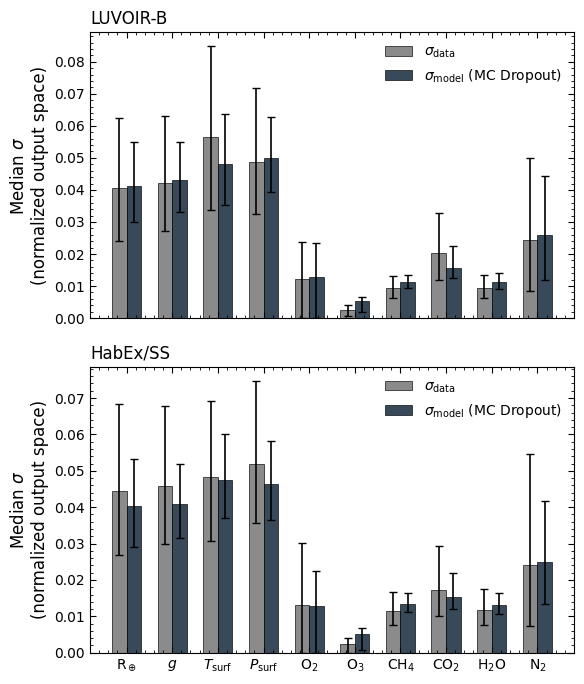

In [12]:
# Figure 1: Median data uncertainty per parameter, LUVOIR vs HabEx (vertical)
fig, axes = plt.subplots(2, 1, figsize=(6, 7), sharex=True, sharey=False)
x_pos = np.arange(N_PARAMS)

for ax, tel_lbl, std_d, std_m in zip(
    axes,
    ["LUVOIR-B", "HabEx/SS"],
    [std_data_LU, std_data_HB],
    [std_model_LU, std_model_HB],
):
    med_d = np.median(std_d, axis=0)
    med_m = np.median(std_m, axis=0)
    q25_d = np.percentile(std_d, 25, axis=0)
    q75_d = np.percentile(std_d, 75, axis=0)
    q25_m = np.percentile(std_m, 25, axis=0)
    q75_m = np.percentile(std_m, 75, axis=0)

    w = 0.32
    ax.bar(
        x_pos - w / 2,
        med_d,
        w,
        color="tab:gray",
        alpha=0.9,
        label=r"$\sigma_{\rm data}$",
        edgecolor="k",
        linewidth=0.5,
    )
    ax.errorbar(
        x_pos - w / 2,
        med_d,
        yerr=[med_d - q25_d, q75_d - med_d],
        fmt="none",
        color="k",
        capsize=3,
        linewidth=1.2,
    )

    ax.bar(
        x_pos + w / 2,
        med_m,
        w,
        color="#223648",
        alpha=0.9,
        label=r"$\sigma_{\rm model}$ (MC Dropout)",
        edgecolor="k",
        linewidth=0.5,
    )
    ax.errorbar(
        x_pos + w / 2,
        med_m,
        yerr=[med_m - q25_m, q75_m - med_m],
        fmt="none",
        color="k",
        capsize=3,
        linewidth=1.2,
    )

    ax.set_ylabel(r"Median $\sigma$" + "\n(normalized output space)")
    ax.set_title(tel_lbl, loc="left")
    ax.legend()

axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels(PARAM_LABELS)

plt.tight_layout()
plt.savefig("../images/data_vs_model_uncertainty.pdf", dpi=200, bbox_inches="tight")
plt.show()

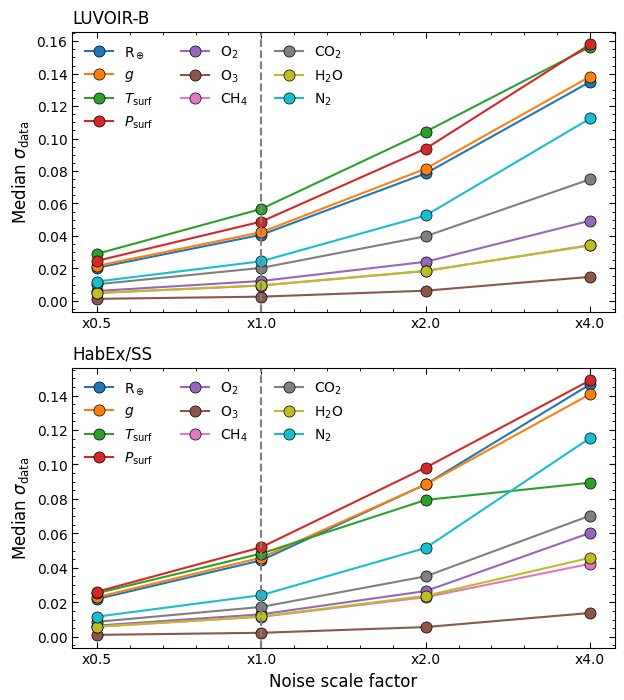

In [13]:
# Figure 2: Data uncertainty vs noise scale factor
cmap = mpl.colormaps["tab10"]
colors = [cmap(i) for i in range(N_PARAMS)]

fig, axes = plt.subplots(2, 1, figsize=(7, 8))
scale_labels = [f"x{s}" for s in SNR_SCALES]
x_snr = np.arange(len(SNR_SCALES))

for ax, tel in zip(axes, ["LUVOIR", "HABEX"]):
    for j, (lbl, col) in enumerate(zip(PARAM_LABELS, colors)):
        medians = [
            np.median(get_std_matrix(snr_results[tel][s])[:, j]) for s in SNR_SCALES
        ]
        ax.plot(
            x_snr,
            medians,
            "o-",
            color=col,
            label=lbl,
            markersize=8,
            markeredgecolor="k",
            markeredgewidth=0.5,
        )

    ax.set_xticks(x_snr)
    ax.set_xticklabels(scale_labels)
    ax.set_ylabel(r"Median $\sigma_{\rm data}$")
    ax.set_title(
        {"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel],
        loc="left",
    )
    ax.axvline(1, linestyle="--", color="gray")
    ax.legend(ncols=3)

axes[1].set_xlabel("Noise scale factor")

plt.savefig("../images/data_uncertainty_vs_s.pdf", dpi=200, bbox_inches="tight")
plt.show()

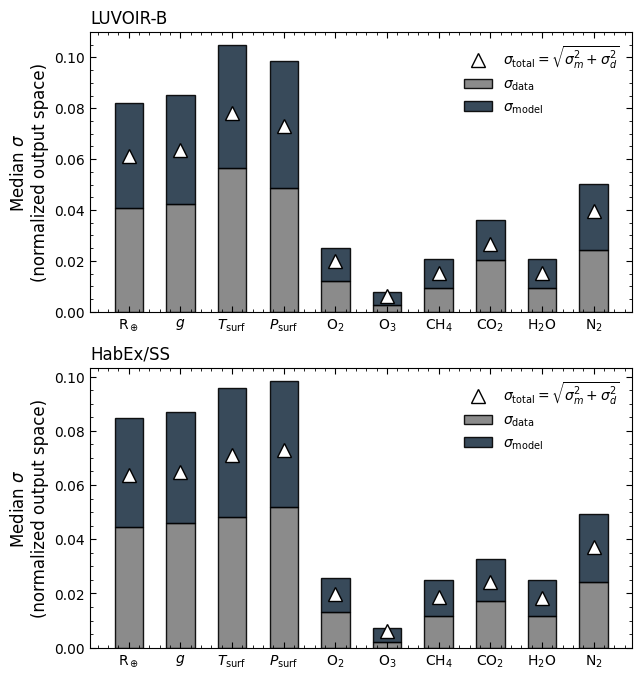

In [14]:
# Figure 3: Stacked uncertainty breakdown
fig, axes = plt.subplots(2, 1, figsize=(7, 8))
x_pos = np.arange(N_PARAMS)
bar_w = 0.55

for ax, tel_lbl, std_d, std_m, std_t in zip(
    axes,
    ["LUVOIR-B", "HabEx/SS"],
    [std_data_LU, std_data_HB],
    [std_model_LU, std_model_HB],
    [total_std_LU, total_std_HB],
):
    med_d = np.median(std_d, axis=0)
    med_m = np.median(std_m, axis=0)

    ax.bar(
        x_pos,
        med_d,
        bar_w,
        color="tab:gray",
        alpha=0.90,
        edgecolor="k",
        label=r"$\sigma_{\rm data}$",
    )
    ax.bar(
        x_pos,
        med_m,
        bar_w,
        bottom=med_d,
        color="#223648",
        alpha=0.90,
        edgecolor="k",
        label=r"$\sigma_{\rm model}$",
    )

    # Mark the quadratic total (it lies below the stacked sum)
    med_t = np.median(std_t, axis=0)
    ax.plot(
        x_pos,
        med_t,
        "^",
        color="white",
        markersize=10,
        markeredgecolor="k",
        zorder=5,
        label=r"$\sigma_{\rm total} = \sqrt{\sigma_m^2+\sigma_d^2}$",
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_LABELS)
    ax.set_ylabel(r"Median $\sigma$" + "\n(normalized output space)")
    ax.set_title(tel_lbl, loc="left")
    ax.legend()

plt.savefig("../images/total_uncertainty_breakdown.pdf", dpi=200, bbox_inches="tight")
plt.show()

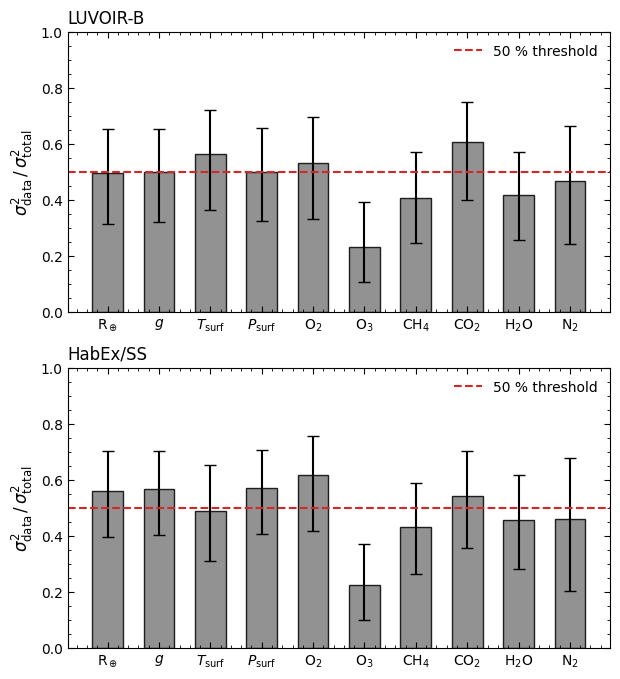

In [15]:
# Figure 4: Fraction of total variance due to data uncertainty
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharey=True)
x_pos = np.arange(N_PARAMS)

for ax, tel_lbl, std_d, std_t in zip(
    axes,
    ["LUVOIR-B", "HabEx/SS"],
    [std_data_LU, std_data_HB],
    [total_std_LU, total_std_HB],
):
    # Per-sample fraction of variance due to data uncertainty
    # Avoid division by zero
    var_d = std_d**2
    var_t = std_t**2
    with np.errstate(divide="ignore", invalid="ignore"):
        frac = np.where(var_t > 0, var_d / var_t, np.nan)

    med_frac = np.nanmedian(frac, axis=0)
    q25_frac = np.nanpercentile(frac, 25, axis=0)
    q75_frac = np.nanpercentile(frac, 75, axis=0)

    ax.bar(
        x_pos,
        med_frac,
        0.6,
        color="tab:gray",
        alpha=0.85,
        edgecolor="k",
    )
    ax.errorbar(
        x_pos,
        med_frac,
        yerr=[med_frac - q25_frac, q75_frac - med_frac],
        fmt="none",
        color="k",
        capsize=4,
    )

    ax.axhline(0.5, linestyle="--", color="tab:red", label="50 % threshold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_LABELS)
    ax.set_ylabel(r"$\sigma^2_{\rm data}\,/\,\sigma^2_{\rm total}$")
    ax.set_ylim(0, 1)
    ax.set_title(tel_lbl, loc="left")
    ax.legend()

plt.savefig("../images/data_uncertainty_fraction.pdf", dpi=200, bbox_inches="tight")
plt.show()

# Sigma Coverage Calibration

In [16]:
# Build sigma-coverage fractions
# Display names (must match iteration order of ALL_PARAMS)
def _get_mean_matrix(result):
    """Concatenate per-head mean predictions to (N, 10) in normalised output space."""
    return np.concatenate(
        [
            result["physical"]["mean"],
            result["main_chem"]["mean"],
            result["other_chem"]["mean"],
        ],
        axis=1,
    )


def _get_true_matrix(labels):
    """Transform ground-truth labels to model output space to (N, 10)."""
    cols = []

    # Physical outputs: min-max then power transform (same as training parser)
    for p in PHYS_PARAMS:
        y = labels[p].astype(np.float32)
        if p == "ATMOSPHERE-TEMPERATURE":
            y = np.where(y == 273.15, y + 2e-5, y)
        s = norm_stats["outputs"][p]
        z = (y - s["min"]) / (s["max"] - s["min"])
        cols.append(np.power(z, 1.0 / s["best_n"]))

    # Chemical outputs: power transform only (same as training parser)
    for p in MAIN_CHEM + OTHER_CHEM:
        best_n = norm_stats["outputs"][p]["best_n"]
        cols.append(np.power(labels[p].astype(np.float32), 1.0 / best_n))

    return np.column_stack(cols)


def _build_sigma_fractions_from_std(
    std_mat, mean_mat, true_mat, labels, param_names, eras
):
    """Build nested sigma-coverage dict using residual = |y_hat - y_true| / sigma."""
    resid = np.abs(mean_mat - true_mat) / (std_mat + 1e-12)
    out = {}
    for era in eras:
        mask = labels["Earth_type"] == era
        out[era] = {}
        for j, pname in enumerate(param_names):
            r_j = resid[mask, j]
            prev = 0.0
            out[era][pname] = {}
            for sig in [1, 2, 3]:
                frac = float(np.mean(r_j <= sig))
                out[era][pname][sig] = {
                    "fraction_of_sigma": frac,
                    "complementary_fraction_of_sigma": frac - prev,
                }
                prev = frac
            out[era][pname]["higher"] = {
                "fraction_of_sigma": 1.0,
                "complementary_fraction_of_sigma": 1.0 - prev,
            }
    return out


_ERA_ORDER_SIG = ["modern", "proterozoic", "archean"]

# Point estimates in normalized output space
mean_pred_model_LU = _get_mean_matrix(mc_LU)
mean_pred_model_HB = _get_mean_matrix(mc_HB)
mean_pred_data_LU = _get_mean_matrix(bs_LU_default)
mean_pred_data_HB = _get_mean_matrix(bs_HB_default)

# Ground truth in same space
true_LU = _get_true_matrix(lab_LU)
true_HB = _get_true_matrix(lab_HB)

# Three sigma-fractions sets in Notebook 13 style
sigma_fractions_model = {
    "luvoir": _build_sigma_fractions_from_std(
        std_model_LU,
        mean_pred_model_LU,
        true_LU,
        lab_LU,
        PARAM_LABELS,
        _ERA_ORDER_SIG,
    ),
    "habex": _build_sigma_fractions_from_std(
        std_model_HB,
        mean_pred_model_HB,
        true_HB,
        lab_HB,
        PARAM_LABELS,
        _ERA_ORDER_SIG,
    ),
}

sigma_fractions_data = {
    "luvoir": _build_sigma_fractions_from_std(
        std_data_LU,
        mean_pred_data_LU,
        true_LU,
        lab_LU,
        PARAM_LABELS,
        _ERA_ORDER_SIG,
    ),
    "habex": _build_sigma_fractions_from_std(
        std_data_HB,
        mean_pred_data_HB,
        true_HB,
        lab_HB,
        PARAM_LABELS,
        _ERA_ORDER_SIG,
    ),
}

sigma_fractions_total = {
    "luvoir": _build_sigma_fractions_from_std(
        total_std_LU,
        mean_pred_model_LU,
        true_LU,
        lab_LU,
        PARAM_LABELS,
        _ERA_ORDER_SIG,
    ),
    "habex": _build_sigma_fractions_from_std(
        total_std_HB,
        mean_pred_model_HB,
        true_HB,
        lab_HB,
        PARAM_LABELS,
        _ERA_ORDER_SIG,
    ),
}

In [17]:
# Figure 5
def plot_sigma_coverage(sigma_fractions, param_names, save_path=None):
    """
    Stacked horizontal bar chart showing sigma coverage per parameter.
    """

    def _split(counts_dict, pnames):
        f1 = np.clip([counts_dict[p][1]["fraction_of_sigma"] for p in pnames], 0, 1)
        f2 = np.clip([counts_dict[p][2]["fraction_of_sigma"] for p in pnames], 0, 1)
        f3 = np.clip([counts_dict[p][3]["fraction_of_sigma"] for p in pnames], 0, 1)
        f1, f2, f3 = np.array(f1, float), np.array(f2, float), np.array(f3, float)
        return {
            "w": {
                1: f1,
                2: np.clip(f2 - f1, 0, 1),
                3: np.clip(f3 - f2, 0, 1),
                "higher": np.clip(1 - f3, 0, 1),
            },
            "cum": {1: f1, 2: f2, 3: f3, "higher": 1.0},
        }

    def _annotate(ax, container, widths, cum_vals, lefts):
        for rect, w, c, left in zip(container.patches, widths, cum_vals, lefts):
            if w < 0.05:
                continue
            x = left + w / 2
            y = rect.get_y() + rect.get_height() / 2
            ax.text(
                x,
                y,
                f"{c * 100:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="k",
                fontweight="bold",
            )

    era_colors = {
        "modern": ["#E1F5FE", "#4FC3F7", "#0288D1"],
        "proterozoic": ["#E8F5E9", "#81C784", "#388E3C"],
        "archean": ["#FFF3E0", "#FFB74D", "#F57C00"],
    }
    gray = "#BDBDBD"
    # Gaussian reference fractions for 1σ, 2σ, 3σ
    gauss_ref = {1: 0.6827, 2: 0.9545, 3: 0.9973}

    telescopes = ["luvoir", "habex"]
    eras = ["modern", "proterozoic", "archean"]
    y_pos = np.arange(len(param_names))
    bar_h = 0.70

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 7), sharey=True)

    for i, tel in enumerate(telescopes):
        for j, era in enumerate(eras):
            ax = axes[i, j]
            data = _split(sigma_fractions[tel][era], param_names)

            left = np.zeros(len(param_names))
            for sig, color, label in [
                (1, era_colors[era][0], r"$1\sigma$"),
                (2, era_colors[era][1], r"$2\sigma$"),
                (3, era_colors[era][2], r"$3\sigma$"),
                ("higher", gray, r"$>3\sigma$"),
            ]:
                bc = ax.barh(
                    y_pos,
                    data["w"][sig],
                    bar_h,
                    left=left,
                    color=color,
                    edgecolor="darkgray",
                    alpha=0.90,
                    label=label,
                )
                if sig != "higher":
                    _annotate(ax, bc, data["w"][sig], data["cum"][sig], left)
                left = left + data["w"][sig]

            # Gaussian reference lines
            for _, xref in gauss_ref.items():
                ax.axvline(
                    xref,
                    color="tab:red",
                    linestyle=":",
                    zorder=5,
                )

            ax.set_xlim(0, 1)
            ax.margins(y=0.05)
            ax.invert_yaxis()
            ax.set_axisbelow(True)

            tel_name = "LUVOIR-B" if tel == "luvoir" else "HabEx/SS"
            ax.set_title(f"{tel_name} - {era.title()}", loc="left", pad=8)

            if i == 0:
                ax.set_xticks([])
            else:
                x_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
                ax.set_xticks(x_ticks)
                ax.set_xticklabels([f"{t:.1f}" for t in x_ticks])
                ax.set_xlabel("Sample fraction")
                ax.legend(
                    loc="lower center",
                    ncols=4,
                    bbox_to_anchor=(0.5, 2.35),
                    columnspacing=0.8,
                )

    for ax in axes[:, 0]:
        ax.invert_yaxis()
        ax.set_yticks(y_pos)
        ax.set_yticklabels(param_names)
        ax.tick_params(axis="y", labelleft=True)

    plt.subplots_adjust(left=0.14, bottom=0.02, wspace=0.1, hspace=0.2)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"{save_path}")

    plt.show()

../images/sigma_coverage_bootstrap.pdf


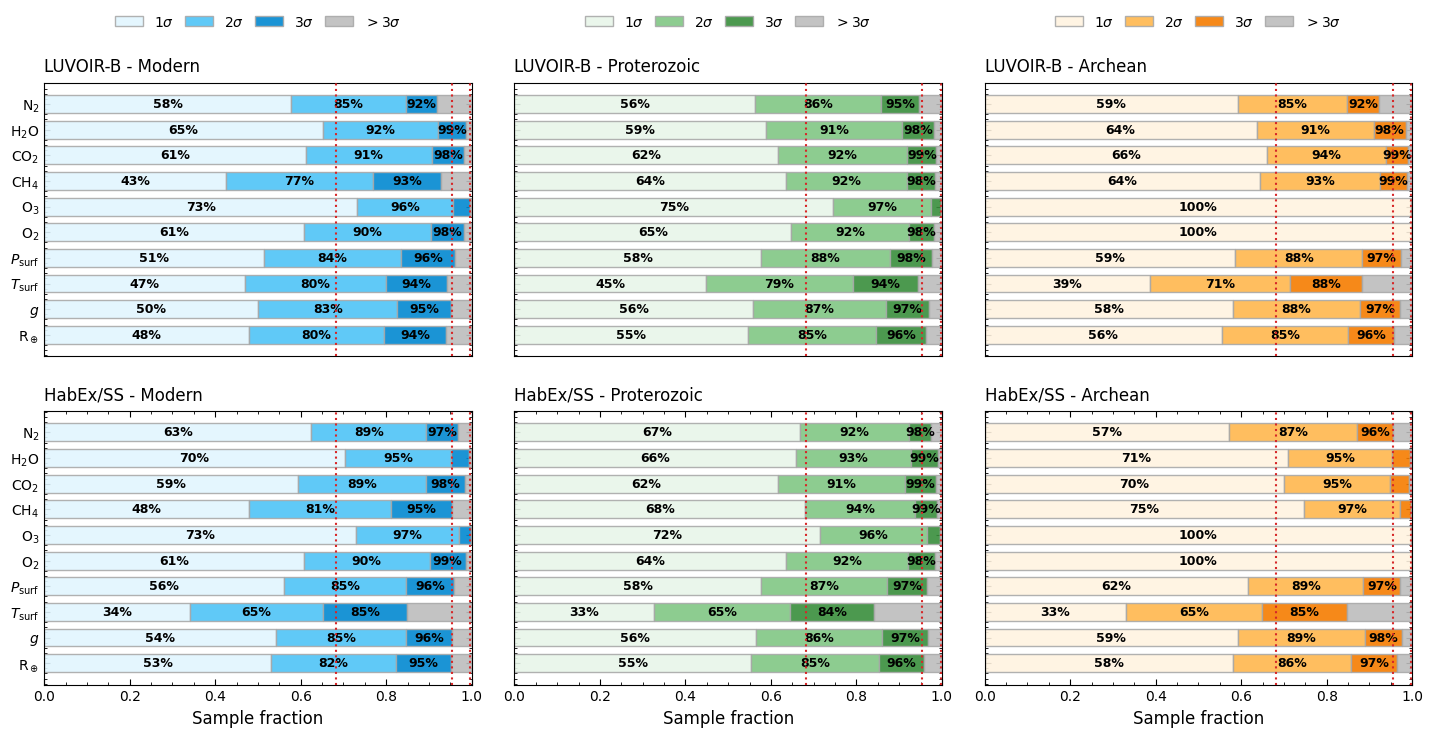

In [18]:
plot_sigma_coverage(
    sigma_fractions_total,
    PARAM_LABELS,
    save_path="../images/sigma_coverage_bootstrap.pdf",
)

In [19]:
def plot_delta(sf_a, sf_b, label_a, label_b, sigma_level=1, save_path=None):
    """Delta coverage plot in the same style used in Notebook 13."""
    params = PARAM_LABELS
    telescopes = ["luvoir", "habex"]
    tel_names = {"luvoir": "LUVOIR-B", "habex": "HabEx/SS"}
    y = np.arange(len(params))

    fig, axes = plt.subplots(2, 3, figsize=(18, 6), sharey=True)
    fig.suptitle(
        rf"$\Delta${sigma_level}$\sigma$ coverage  [{label_b} - {label_a}]",
        y=1.02,
    )

    all_d = {}
    vmax = 0.0
    for tel in telescopes:
        all_d[tel] = {}
        for era in _ERA_ORDER_SIG:
            if era not in sf_a.get(tel, {}) or era not in sf_b.get(tel, {}):
                continue
            d = np.array(
                [
                    sf_b[tel][era][p][sigma_level]["fraction_of_sigma"]
                    - sf_a[tel][era][p][sigma_level]["fraction_of_sigma"]
                    for p in params
                ]
            )
            all_d[tel][era] = d
            vmax = max(vmax, np.abs(d).max())

    vmax = max(vmax, 0.01)

    for i, tel in enumerate(telescopes):
        for j, era in enumerate(_ERA_ORDER_SIG):
            ax = axes[i, j]
            if era not in all_d.get(tel, {}):
                continue
            d = all_d[tel][era]
            ax.barh(
                y,
                d,
                0.72,
                color=["#1976D2" if v >= 0 else "#D32F2F" for v in d],
                edgecolor="darkgray",
                alpha=0.85,
            )
            ax.axvline(0, color="black", lw=0.9)
            for yi, v in zip(y, d):
                if abs(v) > 0.005:
                    ax.text(
                        v + (0.003 if v >= 0 else -0.003),
                        yi,
                        f"{v:+.3f}",
                        ha="left" if v >= 0 else "right",
                        va="center",
                        fontsize=8,
                    )
            ax.set_title(f"{tel_names[tel]} — {era.title()}", loc="left")
            ax.set_xlim(-vmax * 1.35, vmax * 1.35)
            ax.invert_yaxis()
            ax.margins(y=0.05)
            if i == 1:
                ax.set_xlabel(rf"$\Delta${sigma_level}$\sigma$ fraction")
            if j == 0:
                ax.set_yticks(y)
                ax.set_yticklabels(params)

    fig.legend(
        handles=[
            mpl.patches.Patch(color="#1976D2", label=f"{label_b} > {label_a}"),
            mpl.patches.Patch(color="#D32F2F", label=f"{label_b} < {label_a}"),
        ],
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, -0.04),
    )
    plt.subplots_adjust(left=0.14, wspace=0.09, hspace=0.3)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

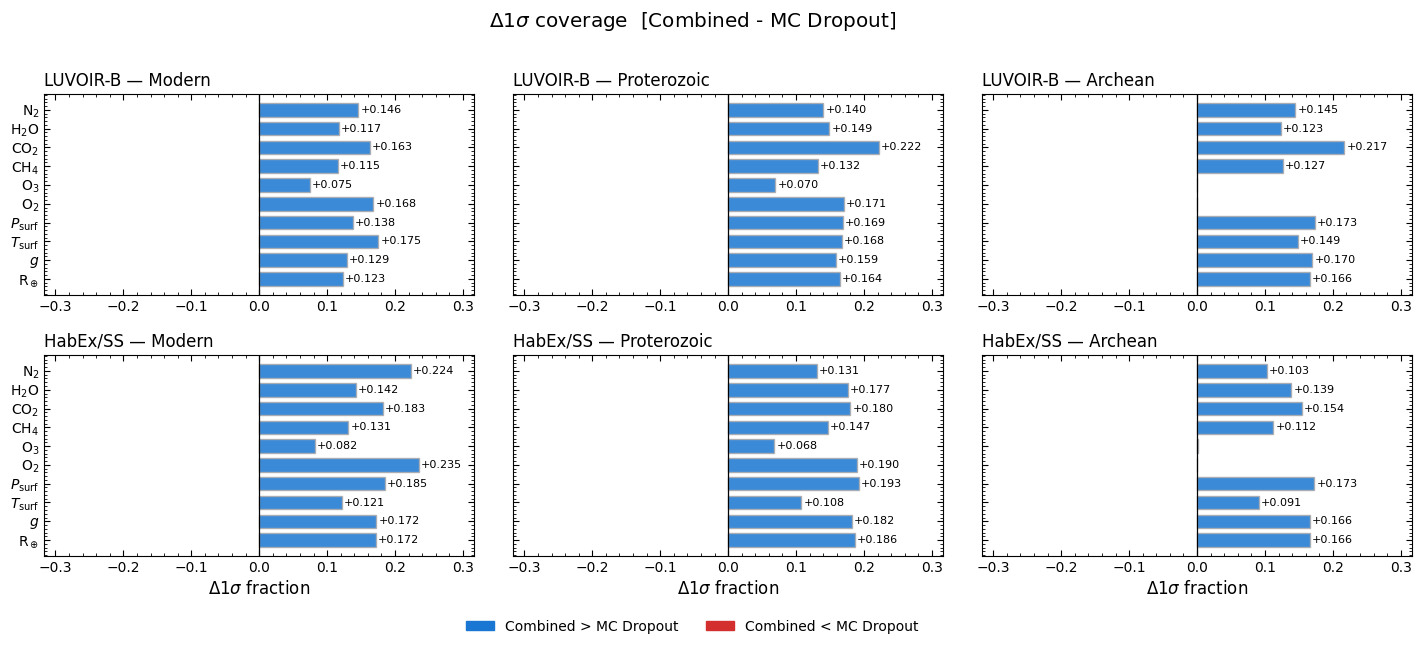

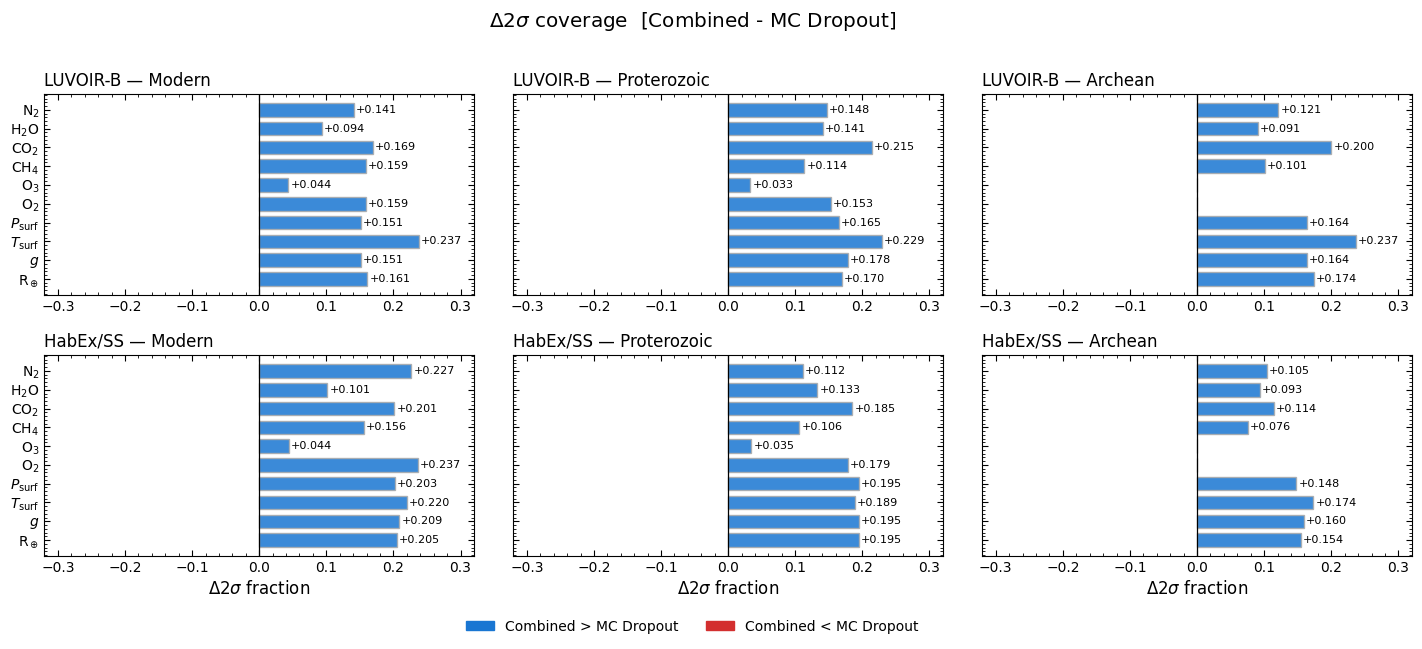

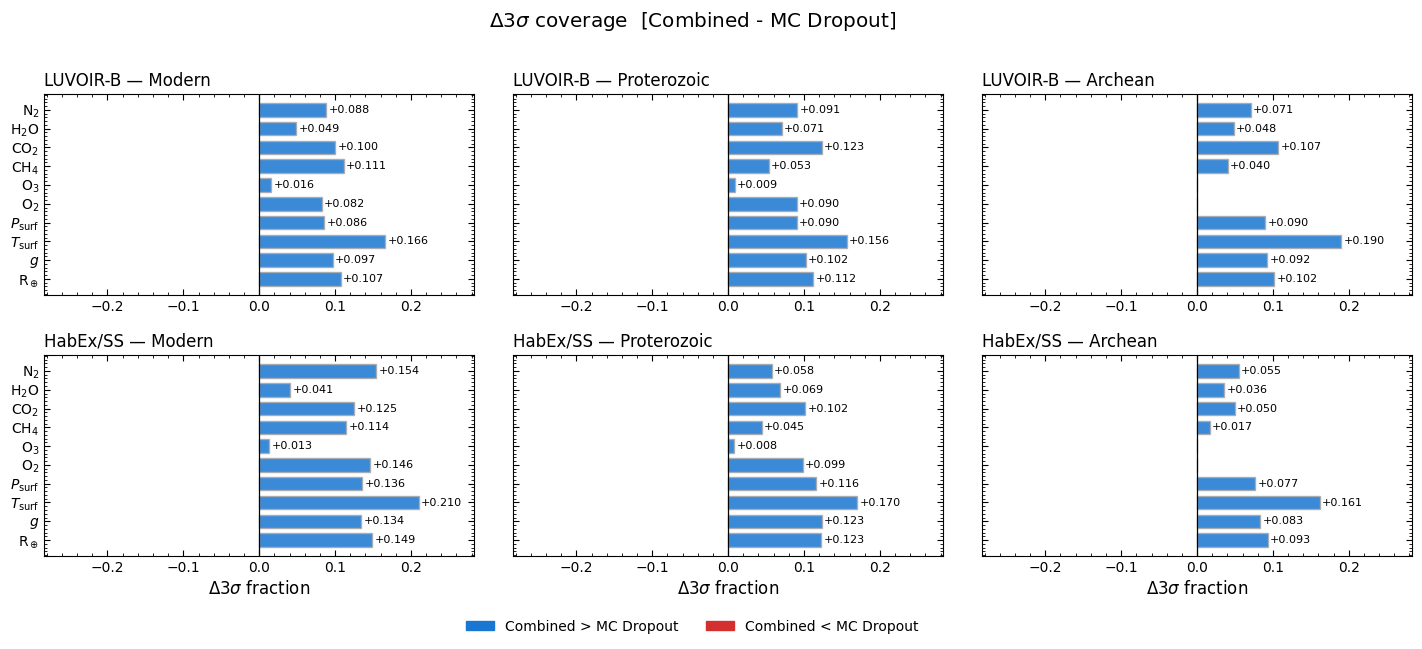

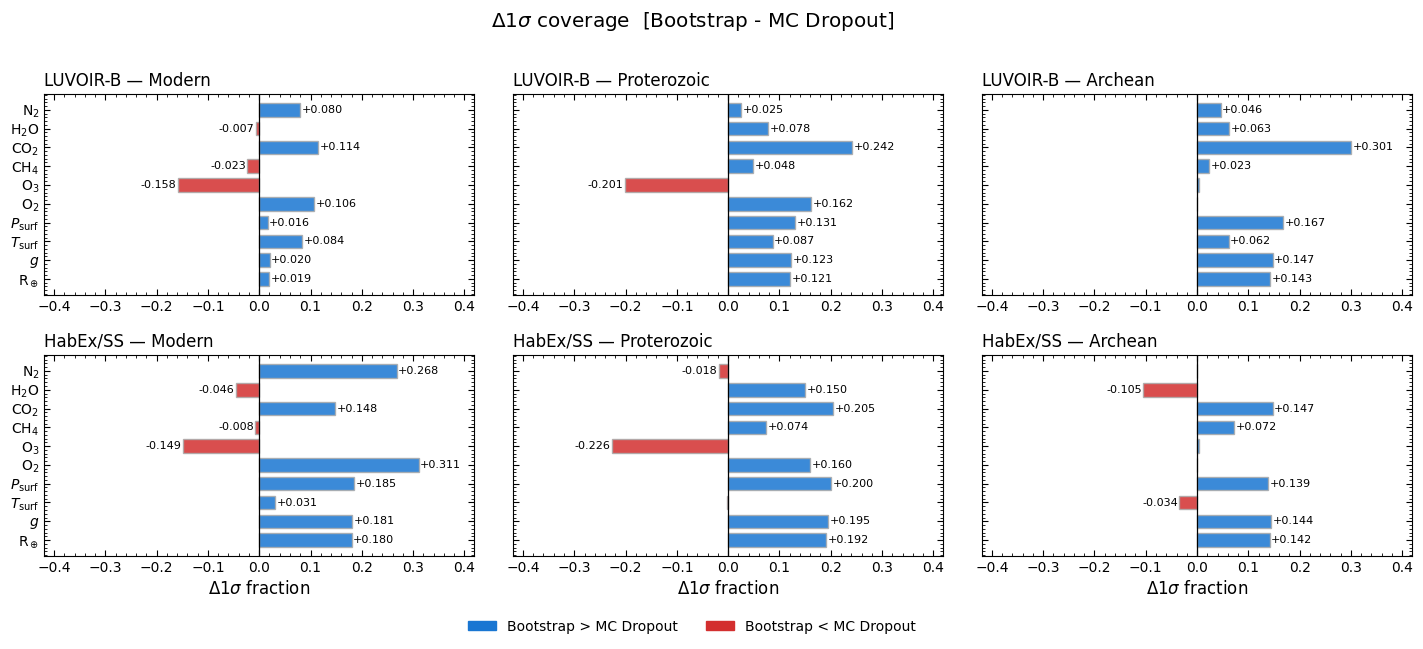

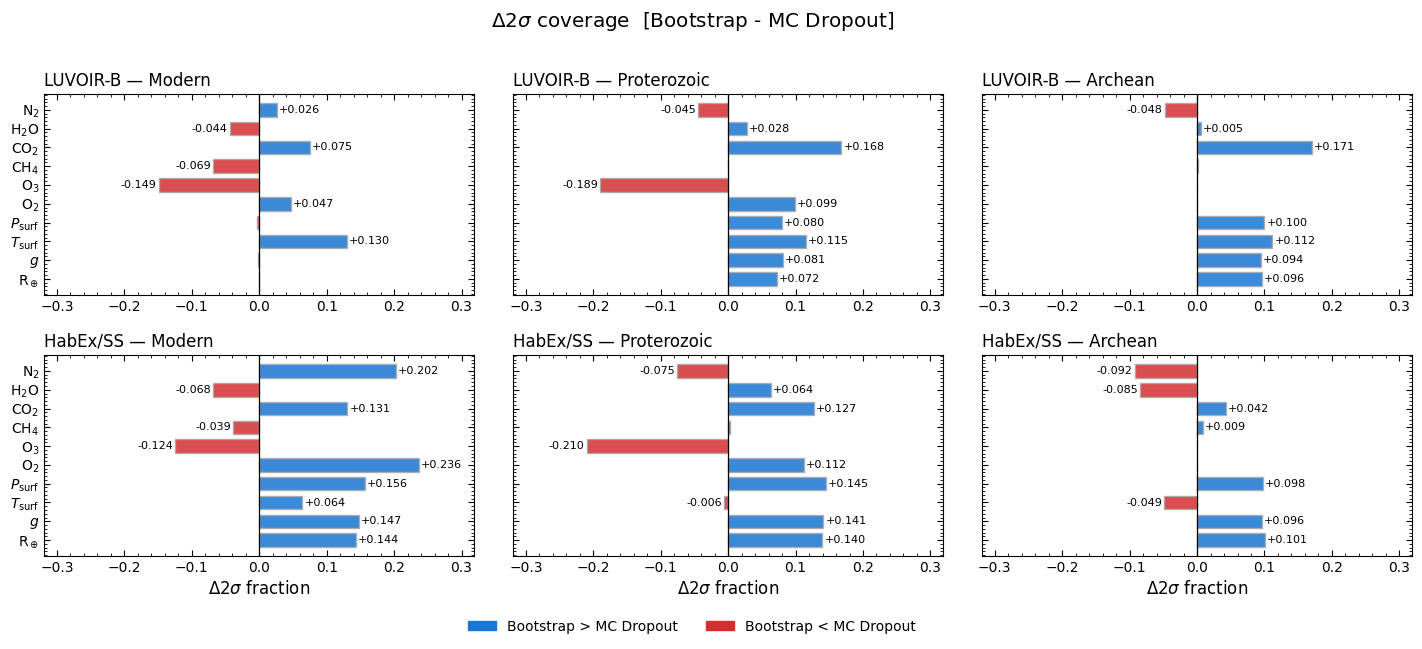

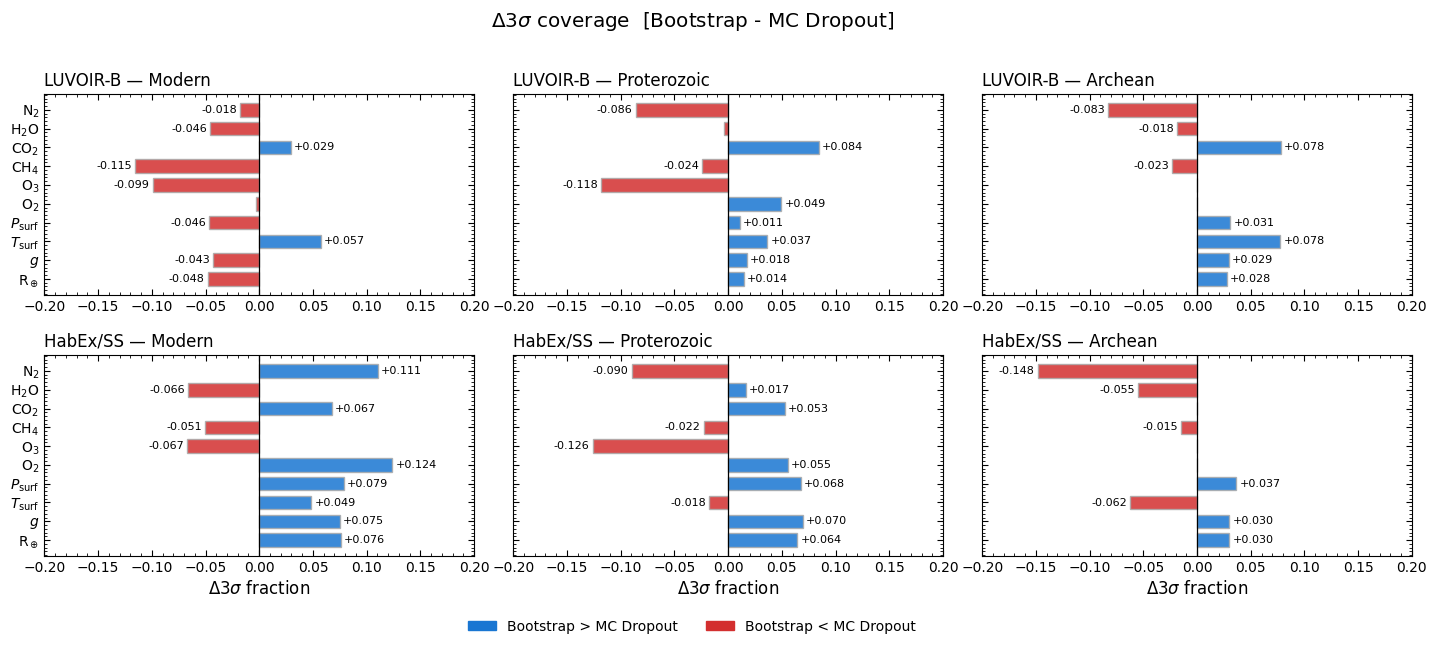

In [21]:
for s in [1, 2, 3]:
    plot_delta(
        sigma_fractions_model,
        sigma_fractions_total,
        "MC Dropout",
        "Combined",
        sigma_level=s,
        save_path=f"../images/delta_combined_vs_mc_{s}sigma_bootstrap.pdf",
    )

for s in [1, 2, 3]:
    plot_delta(
        sigma_fractions_model,
        sigma_fractions_data,
        "MC Dropout",
        "Bootstrap",
        sigma_level=s,
        save_path=f"../images/delta_bs_vs_mc_{s}sigma_bootstrap.pdf",
    )

# Corner Plots

In [22]:
B_CORNER = 5000
N_MC_CORNER = 5000

_WAVE = {
    "LUVOIR": np.concatenate(
        [
            np.geomspace(0.200, 0.509, 8),
            np.geomspace(0.515, 0.998, 94),
            np.geomspace(1.010, 1.995, 49),
        ]
    ),
    "HABEX": np.concatenate(
        [
            np.geomspace(0.200, 0.446, 7),
            np.geomspace(0.450, 0.971, 109),
            np.geomspace(0.975, 1.763, 25),
        ]
    ),
}

_PHYS_NAMES = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
]
_CHEM_MAIN = ["O2", "O3"]
_CHEM_OTHER = ["CH4", "CO2", "H2O", "N2"]
_ALL_OUT = _PHYS_NAMES + _CHEM_MAIN + _CHEM_OTHER

CORNER_LABELS_FULL = [
    r"$R_\oplus$",
    r"g [m s$^{-2}$]",
    r"$T_{\rm atm}$ [K]",
    r"$P_{\rm atm}$ [mbar]",
    r"$\log_{10}$(O$_2$)",
    r"$\log_{10}$(O$_3$)",
    r"$\log_{10}$(CH$_4$)",
    r"$\log_{10}$(CO$_2$)",
    r"$\log_{10}$(H$_2$O)",
    r"$\log_{10}$(N$_2$)",
]

In [23]:
def _denorm_physical(arr, name):
    """Inverse min-max normalisation for a physical parameter (best_n = 1)."""
    s = norm_stats["outputs"][name]
    return np.asarray(arr) * (s["max"] - s["min"]) + s["min"]


def _denorm_chem_log(arr, name):
    """Inverse power transform for a chemical param → log10(mixing ratio)."""
    best_n = norm_stats["outputs"][name]["best_n"]
    mr = np.clip(np.asarray(arr), 0.0, None) ** best_n
    with np.errstate(divide="ignore"):
        return np.where(mr > 0, np.log10(mr), np.nan)


def _to_physical_matrix(phys, main, other):
    """
    Convert raw model head outputs to a (B, 10) matrix in physical/log10 space.
    Column order: Radius, Gravity, T_atm, P_atm, O2, O3, CH4, CO2, H2O, N2
    """
    cols = [_denorm_physical(phys[:, i], n) for i, n in enumerate(_PHYS_NAMES)]
    cols += [_denorm_chem_log(main[:, i], n) for i, n in enumerate(_CHEM_MAIN)]
    cols += [_denorm_chem_log(other[:, i], n) for i, n in enumerate(_CHEM_OTHER)]
    return np.column_stack(cols)


def _true_values_physical(idx, labels):
    """Extract ground-truth labels for a single sample in physical/log10 space."""
    vals = [float(labels[n][idx]) for n in _PHYS_NAMES]

    for name in _CHEM_MAIN + _CHEM_OTHER:
        mr = float(labels[name][idx])
        vals.append(np.log10(mr) if mr > 0 else np.nan)

    return np.array(vals)


def _single_sample_bootstrap(
    idx, albs, nois, model, telescope, B=500, snr_scale=1.0, seed=SEED
):
    """
    Generate B independent noisy realizations for sample `idx` and pass them
    through the model **deterministically** (training=False) in one batched call.

    Returns (B, 10) matrix in physical/log10 space.
    """
    rng = np.random.default_rng(seed)
    pfx = TELESCOPE_CONFIG[telescope]["prefix"]
    mu, sig = _get_norm_params(telescope)

    x_batch = {}
    for r in ["UV", "Vis", "NIR"]:
        eps = rng.standard_normal((B,) + albs[r][idx].shape).astype(np.float32)
        noisy = (
            albs[r][idx][np.newaxis, :] + eps * nois[r][idx][np.newaxis, :] * snr_scale
        )
        normd = (noisy - mu[r]) / sig[r]
        x_batch[f"NOISY_ALBEDO_{pfx}-{r}"] = tf.constant(normd[:, :, np.newaxis])

    preds = model(x_batch, training=False)
    return _to_physical_matrix(
        preds["physical_output"].numpy(),
        preds["main_chemical_output"].numpy(),
        preds["other_chemical_output"].numpy(),
    )


def _single_sample_mc_dropout(idx, albs, nois, model, telescope, N_MC=500, seed=SEED):
    """
    Run N_MC MC-Dropout passes for a single sample (fixed noise realization).

    The same input is tiled N_MC times; calling model(..., training=True)
    applies an independent SpatialDropout mask per batch element.

    Returns (N_MC, 10) matrix in physical/log10 space.
    """
    rng = np.random.default_rng(seed)
    pfx = TELESCOPE_CONFIG[telescope]["prefix"]
    mu, sig = _get_norm_params(telescope)

    # One fixed noise realization
    noisy_norm = {}
    for r in ["UV", "Vis", "NIR"]:
        eps = rng.standard_normal(albs[r][idx].shape).astype(np.float32)
        noisy_norm[r] = (albs[r][idx] + eps * nois[r][idx] - mu[r]) / sig[r]

    x_batch = {
        f"NOISY_ALBEDO_{pfx}-{r}": tf.constant(
            np.tile(noisy_norm[r][np.newaxis, :, np.newaxis], (N_MC, 1, 1)),
            dtype=tf.float32,
        )
        for r in ["UV", "Vis", "NIR"]
    }
    preds = model(x_batch, training=True)  # dropout ON
    return _to_physical_matrix(
        preds["physical_output"].numpy(),
        preds["main_chemical_output"].numpy(),
        preds["other_chemical_output"].numpy(),
    )

In [24]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def plot_corner_bootstrap(
    sample_idx,
    alb_LU,
    noi_LU,
    lab_LU,
    alb_HB,
    noi_HB,
    lab_HB,
    model_LU,
    model_HB,
    B=500,
    N_MC=500,
    exclude_O2O3=False,
    save_path=None,
    color_bootstrap_lu="#B5D31F",
):
    era = lab_LU["Earth_type"][sample_idx]
    print(f"Sample #{sample_idx}  (Earth type: {era})")

    print(f"  Bootstrap LUVOIR  (B={B})...")
    bs_LU = _single_sample_bootstrap(
        sample_idx, alb_LU, noi_LU, model_LU, "LUVOIR", B=B
    )

    print(f"  Bootstrap HabEx   (B={B})...")
    bs_HB = _single_sample_bootstrap(sample_idx, alb_HB, noi_HB, model_HB, "HABEX", B=B)

    print(f"  MC Dropout LUVOIR (N={N_MC})...")
    mc_s = _single_sample_mc_dropout(
        sample_idx, alb_LU, noi_LU, model_LU, "LUVOIR", N_MC=N_MC
    )

    truths = _true_values_physical(sample_idx, lab_LU)

    col_idx = np.array([i for i in range(10) if not (exclude_O2O3 and i in (4, 5))])
    labels_plot = [CORNER_LABELS_FULL[i] for i in col_idx]

    bs_LU_plot = bs_LU[:, col_idx]
    bs_HB_plot = bs_HB[:, col_idx]
    mc_plot = mc_s[:, col_idx]
    truths_plot = truths[col_idx]

    bs_LU_plot = bs_LU_plot[np.all(np.isfinite(bs_LU_plot), axis=1)]
    bs_HB_plot = bs_HB_plot[np.all(np.isfinite(bs_HB_plot), axis=1)]
    mc_plot = mc_plot[np.all(np.isfinite(mc_plot), axis=1)]

    C_LU = color_bootstrap_lu
    C_HB = "#292929"
    C_MC = "#6B6B6B"
    C_TRUTH = "#C00000"

    levels = (0.393, 0.865)

    # primeira chamada
    fig = corner.corner(
        bs_LU_plot,
        labels=labels_plot,
        truths=truths_plot,
        truth_color=C_TRUTH,
        color=C_LU,
        fill_contours=True,
        plot_density=False,
        plot_datapoints=False,
        quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_fmt=".3f",
        title_kwargs={"fontsize": 25},
        label_kwargs={"fontsize": 22},
        labelpad=0.25,
        max_n_ticks=2,
        hist_kwargs={"linewidth": 1.5},
        contourf_kwargs={"alpha": 0.30},
        contour_kwargs={"linewidths": 1.2},
        levels=levels,
        figsize=(5, 5),
    )

    K = bs_LU_plot.shape[1]
    axes = np.array(fig.axes).reshape((K, K))

    for i in range(K):
        ax = axes[i, i]
        t = ax.title
        t.set_ha("left")
        t.set_x(0.02)

    # overlay Bootstrap HabEx/SS
    corner.corner(
        bs_HB_plot,
        fig=fig,
        color=C_HB,
        fill_contours=True,
        plot_density=False,
        plot_datapoints=False,
        max_n_ticks=2,
        hist_kwargs={"linewidth": 1.5},
        contourf_kwargs={"alpha": 0.30},
        contour_kwargs={"linewidths": 1.2},
        levels=levels,
    )

    # overlay MC Dropout
    corner.corner(
        mc_plot,
        fig=fig,
        color=C_MC,
        fill_contours=False,
        plot_density=False,
        plot_datapoints=False,
        max_n_ticks=2,
        hist_kwargs={"linewidth": 1.8, "linestyle": "--"},
        contour_kwargs={"linewidths": 1.8, "linestyles": "--"},
        levels=levels,
    )

    # tamanho dos ticks
    for ax in fig.axes:
        ax.tick_params(axis="both", which="major", labelsize=20, pad=6)

    fig.subplots_adjust(
        left=0.20,
        right=0.98,
        bottom=0.10,
        top=1,
        wspace=0.05,
        hspace=0.05,
    )

    rng_in = np.random.default_rng(SEED + 99)

    clean_LU = np.concatenate([alb_LU[r][sample_idx] for r in ["UV", "Vis", "NIR"]])
    clean_HB = np.concatenate([alb_HB[r][sample_idx] for r in ["UV", "Vis", "NIR"]])
    noi_LU_1d = np.concatenate([noi_LU[r][sample_idx] for r in ["UV", "Vis", "NIR"]])
    noi_HB_1d = np.concatenate([noi_HB[r][sample_idx] for r in ["UV", "Vis", "NIR"]])

    ax_in = fig.add_axes([0.75, 0.80, 0.37, 0.25])

    for _ in range(30):
        eps = rng_in.standard_normal(len(_WAVE["LUVOIR"])).astype(np.float32)
        ax_in.plot(
            _WAVE["LUVOIR"],
            clean_LU + eps * noi_LU_1d,
            color=C_LU,
            alpha=0.20,
            lw=0.8,
        )

    for _ in range(30):
        eps = rng_in.standard_normal(len(_WAVE["HABEX"])).astype(np.float32)
        ax_in.plot(
            _WAVE["HABEX"],
            clean_HB + eps * noi_HB_1d,
            color=C_HB,
            alpha=0.20,
            lw=0.8,
        )

    ax_in.plot(_WAVE["LUVOIR"], clean_LU, color=C_LU, lw=3, label="LUVOIR-B")
    ax_in.plot(_WAVE["HABEX"], clean_HB, color=C_HB, lw=3, label="HabEx/SS")

    ax_in.set_xlabel(r"Wavelength [$\mu$m]", fontsize=30)
    ax_in.set_ylabel("Apparent Albedo", fontsize=30)
    ax_in.tick_params(axis="both", which="major", labelsize=20)

    ax_in.legend(
        loc="upper right",
        bbox_to_anchor=(0.58, 1.02),
        fontsize=20,
        frameon=False,
    )

    handles = [
        Patch(
            facecolor=C_LU,
            alpha=0.7,
            edgecolor=C_LU,
            label=r"Bootstrap LUVOIR-B  ($\sigma_{\rm data}$)",
        ),
        Patch(
            facecolor=C_HB,
            alpha=0.7,
            edgecolor=C_HB,
            label=r"Bootstrap HabEx/SS  ($\sigma_{\rm data}$)",
        ),
        Line2D(
            [0],
            [0],
            color=C_MC,
            lw=1.8,
            ls="--",
            label=r"MC Dropout LUVOIR-B  ($\sigma_{\rm model}$)",
        ),
        Line2D(
            [0],
            [0],
            color=C_TRUTH,
            lw=1.5,
            ls="--",
            label="True value",
        ),
    ]

    fig.legend(
        handles=handles,
        loc="upper right",
        bbox_to_anchor=(1.1, 0.74),
        fontsize=30,
    )

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"{save_path}")

    plt.show()
    return fig

Sample #3  (Earth type: modern)
  Bootstrap LUVOIR  (B=5000)...
  Bootstrap HabEx   (B=5000)...
  MC Dropout LUVOIR (N=5000)...
../images/cornerplot_bootstrap_modern.pdf


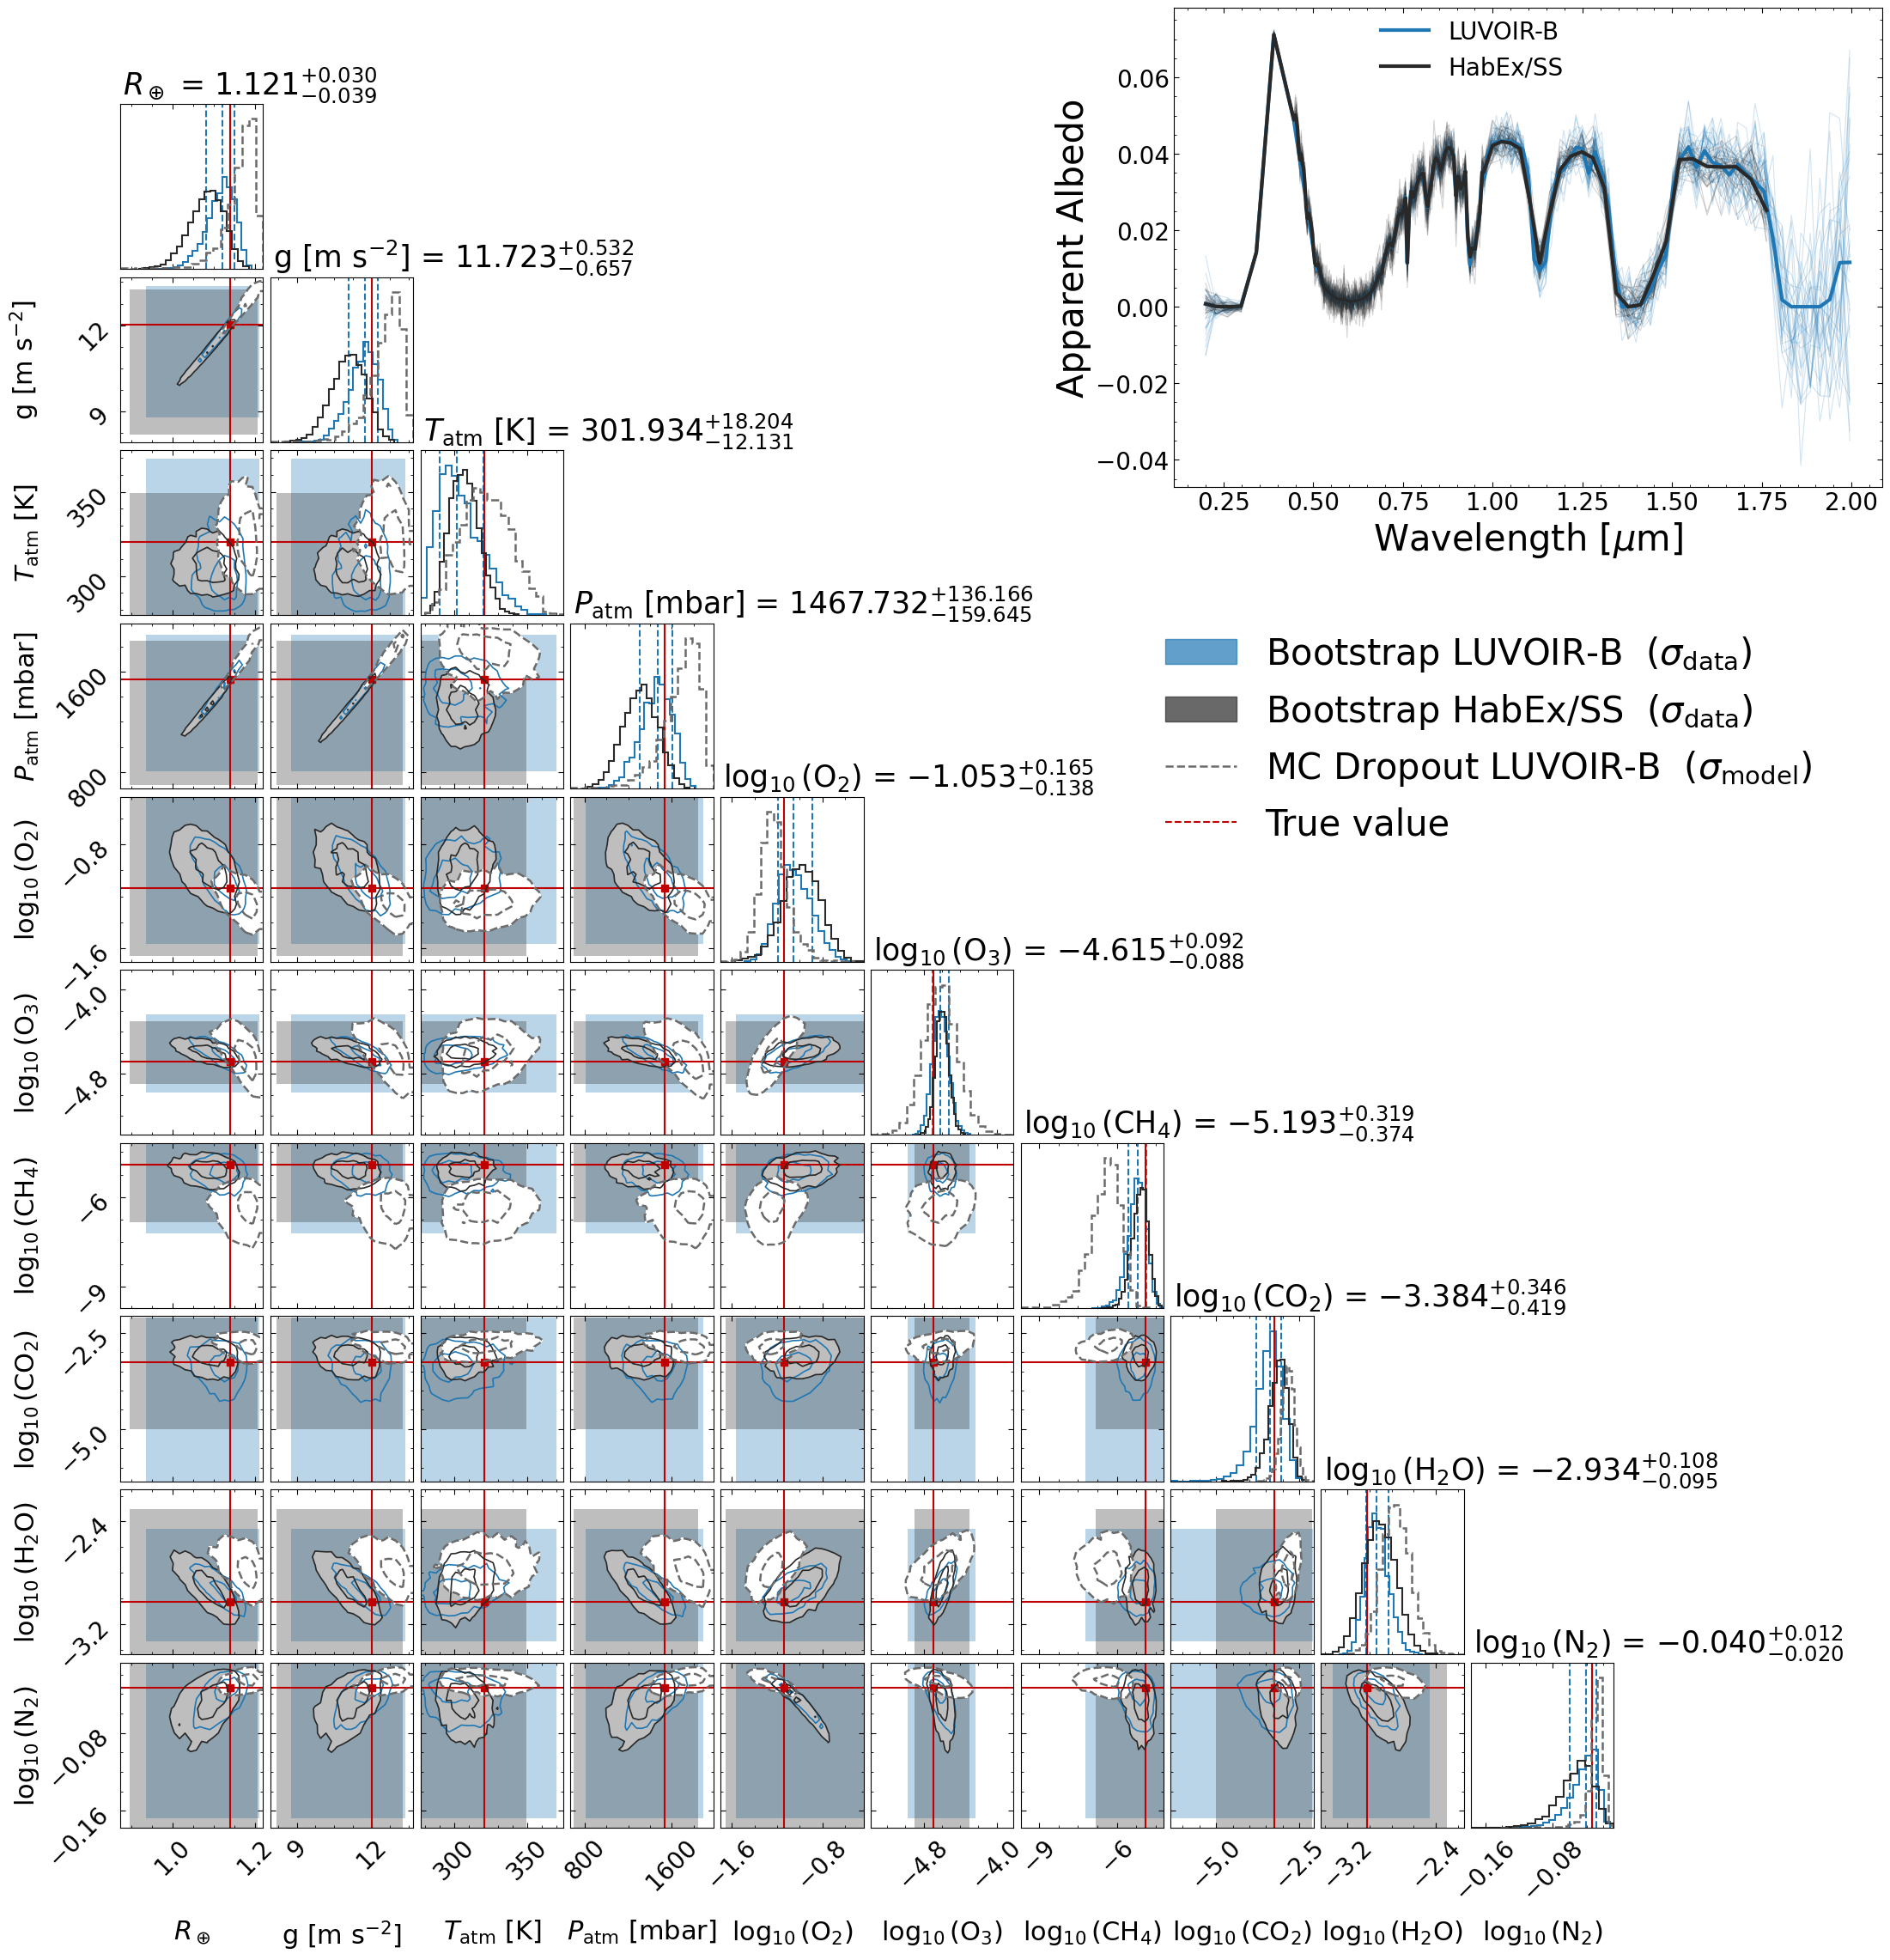

In [25]:
modern_mask = lab_LU["Earth_type"] == "modern"
modern_idx = np.where(modern_mask)[0]

SAMPLE_IDX = None
for candidate in modern_idx:
    best_n_O2 = norm_stats["outputs"]["O2"]["best_n"]
    best_n_O3 = norm_stats["outputs"]["O3"]["best_n"]
    o2_mr = float(lab_LU["O2"][candidate]) ** best_n_O2
    o3_mr = float(lab_LU["O3"][candidate]) ** best_n_O3
    if o2_mr > 1e-6 and o3_mr > 1e-10:
        SAMPLE_IDX = int(candidate)
        break

if SAMPLE_IDX is None:
    SAMPLE_IDX = int(modern_idx[0])
    print(f"Warning: no O2/O3-rich sample found, using idx={SAMPLE_IDX}")
else:
    era = lab_LU["Earth_type"][SAMPLE_IDX]
    print(f"Selected sample: #{SAMPLE_IDX}  (era={era})")
    for name in _PHYS_NAMES:
        val = _denorm_physical(float(lab_LU[name][SAMPLE_IDX]), name)
        print(f"  {name}: {val:.3f}")
    for name in _CHEM_MAIN + _CHEM_OTHER:
        best_n = norm_stats["outputs"][name]["best_n"]
        mr = float(lab_LU[name][SAMPLE_IDX]) ** best_n
        print(f"  {name}: log10 = {np.log10(mr):.2f}")

era = lab_LU["Earth_type"][SAMPLE_IDX]
fig_corner = plot_corner_bootstrap(
    SAMPLE_IDX,
    alb_LU,
    noi_LU,
    lab_LU,
    alb_HB,
    noi_HB,
    lab_HB,
    model_LUVOIR,
    model_HABEX,
    B=B_CORNER,
    N_MC=N_MC_CORNER,
    exclude_O2O3=(era == "archean"),
    save_path="../images/cornerplot_bootstrap_modern.pdf",
    color_bootstrap_lu="tab:blue",
)

Sample #2  (Earth type: proterozoic)
  Bootstrap LUVOIR  (B=5000)...
  Bootstrap HabEx   (B=5000)...
  MC Dropout LUVOIR (N=5000)...
../images/cornerplot_bootstrap_proterozoic.pdf


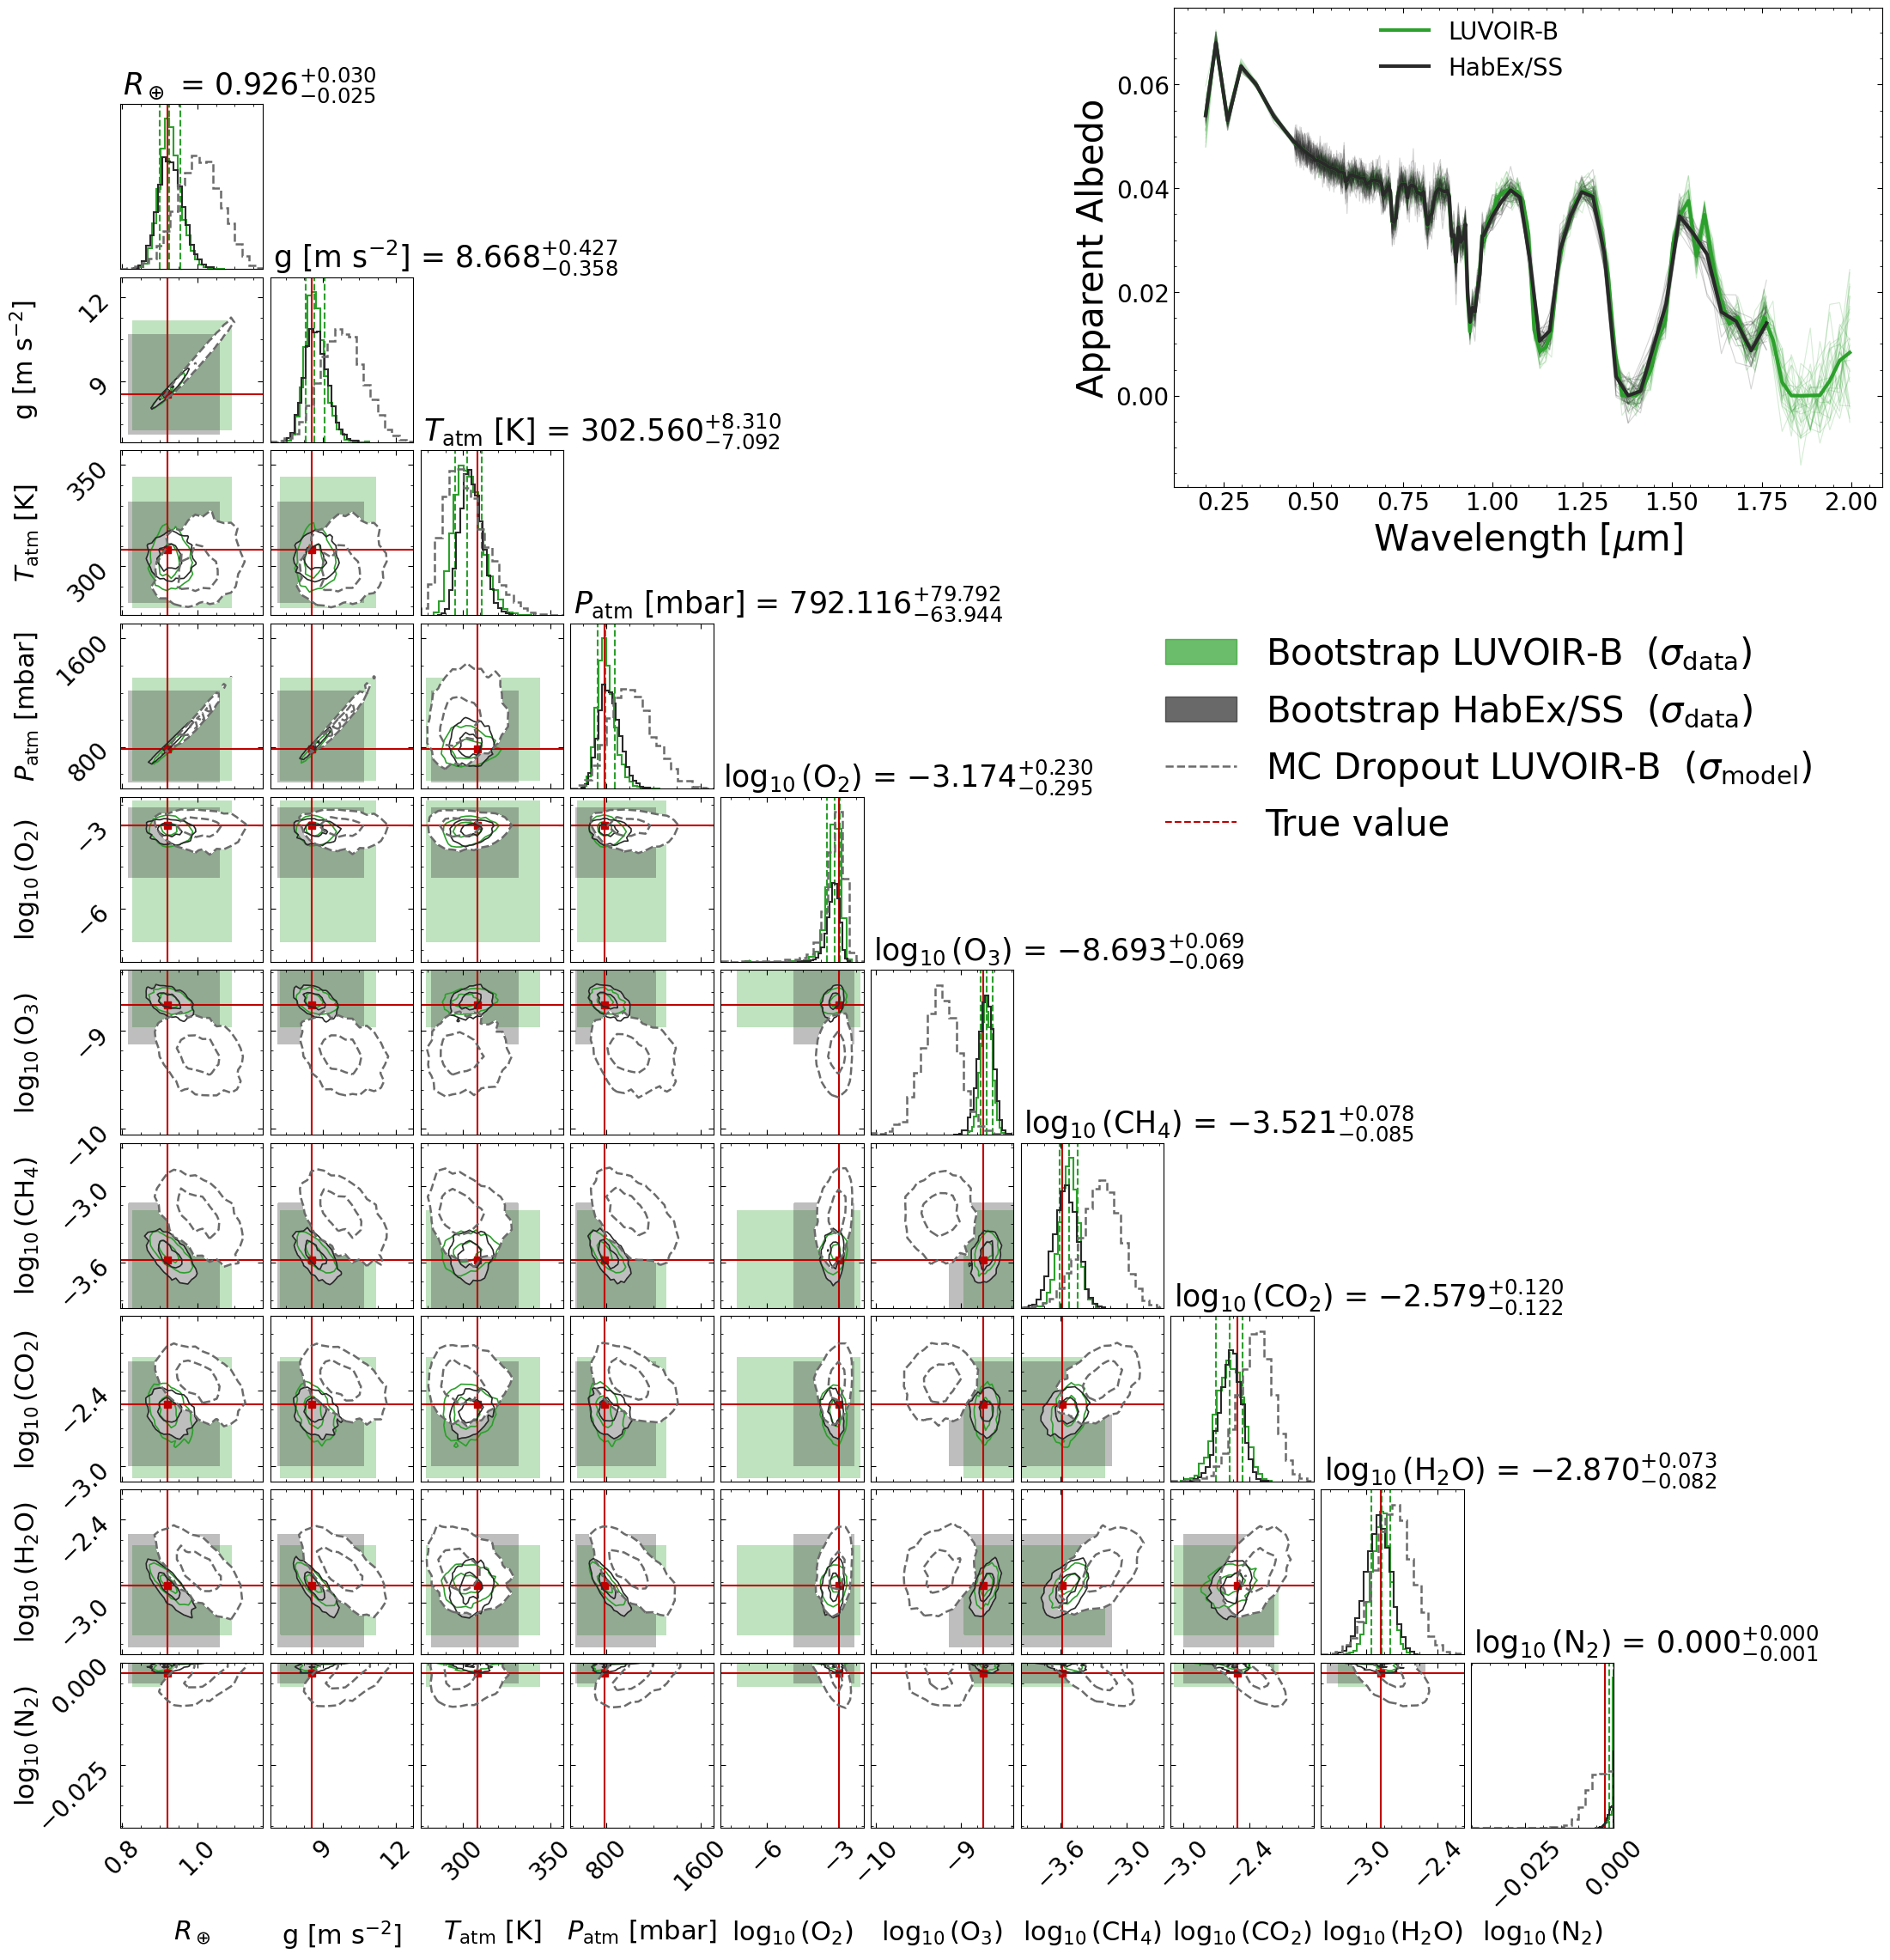

In [26]:
modern_mask = lab_LU["Earth_type"] == "proterozoic"
modern_idx = np.where(modern_mask)[0]

SAMPLE_IDX = None
for candidate in modern_idx:
    best_n_O2 = norm_stats["outputs"]["O2"]["best_n"]
    best_n_O3 = norm_stats["outputs"]["O3"]["best_n"]
    o2_mr = float(lab_LU["O2"][candidate]) ** best_n_O2
    o3_mr = float(lab_LU["O3"][candidate]) ** best_n_O3
    if o2_mr > 1e-6 and o3_mr > 1e-10:
        SAMPLE_IDX = int(candidate)
        break

if SAMPLE_IDX is None:
    SAMPLE_IDX = int(modern_idx[0])
    print(f"Warning: no O2/O3-rich sample found, using idx={SAMPLE_IDX}")
else:
    era = lab_LU["Earth_type"][SAMPLE_IDX]
    print(f"Selected sample: #{SAMPLE_IDX}  (era={era})")
    for name in _PHYS_NAMES:
        val = _denorm_physical(float(lab_LU[name][SAMPLE_IDX]), name)
        print(f"  {name}: {val:.3f}")
    for name in _CHEM_MAIN + _CHEM_OTHER:
        best_n = norm_stats["outputs"][name]["best_n"]
        mr = float(lab_LU[name][SAMPLE_IDX]) ** best_n
        print(f"  {name}: log10 = {np.log10(mr):.2f}")

era = lab_LU["Earth_type"][SAMPLE_IDX]
fig_corner = plot_corner_bootstrap(
    SAMPLE_IDX,
    alb_LU,
    noi_LU,
    lab_LU,
    alb_HB,
    noi_HB,
    lab_HB,
    model_LUVOIR,
    model_HABEX,
    B=B_CORNER,
    N_MC=N_MC_CORNER,
    exclude_O2O3=(era == "archean"),
    save_path="../images/cornerplot_bootstrap_proterozoic.pdf",
    color_bootstrap_lu="tab:green",
)

Sample #0  (Earth type: archean)
  Bootstrap LUVOIR  (B=5000)...
  Bootstrap HabEx   (B=5000)...
  MC Dropout LUVOIR (N=5000)...
../images/cornerplot_bootstrap_archean.pdf


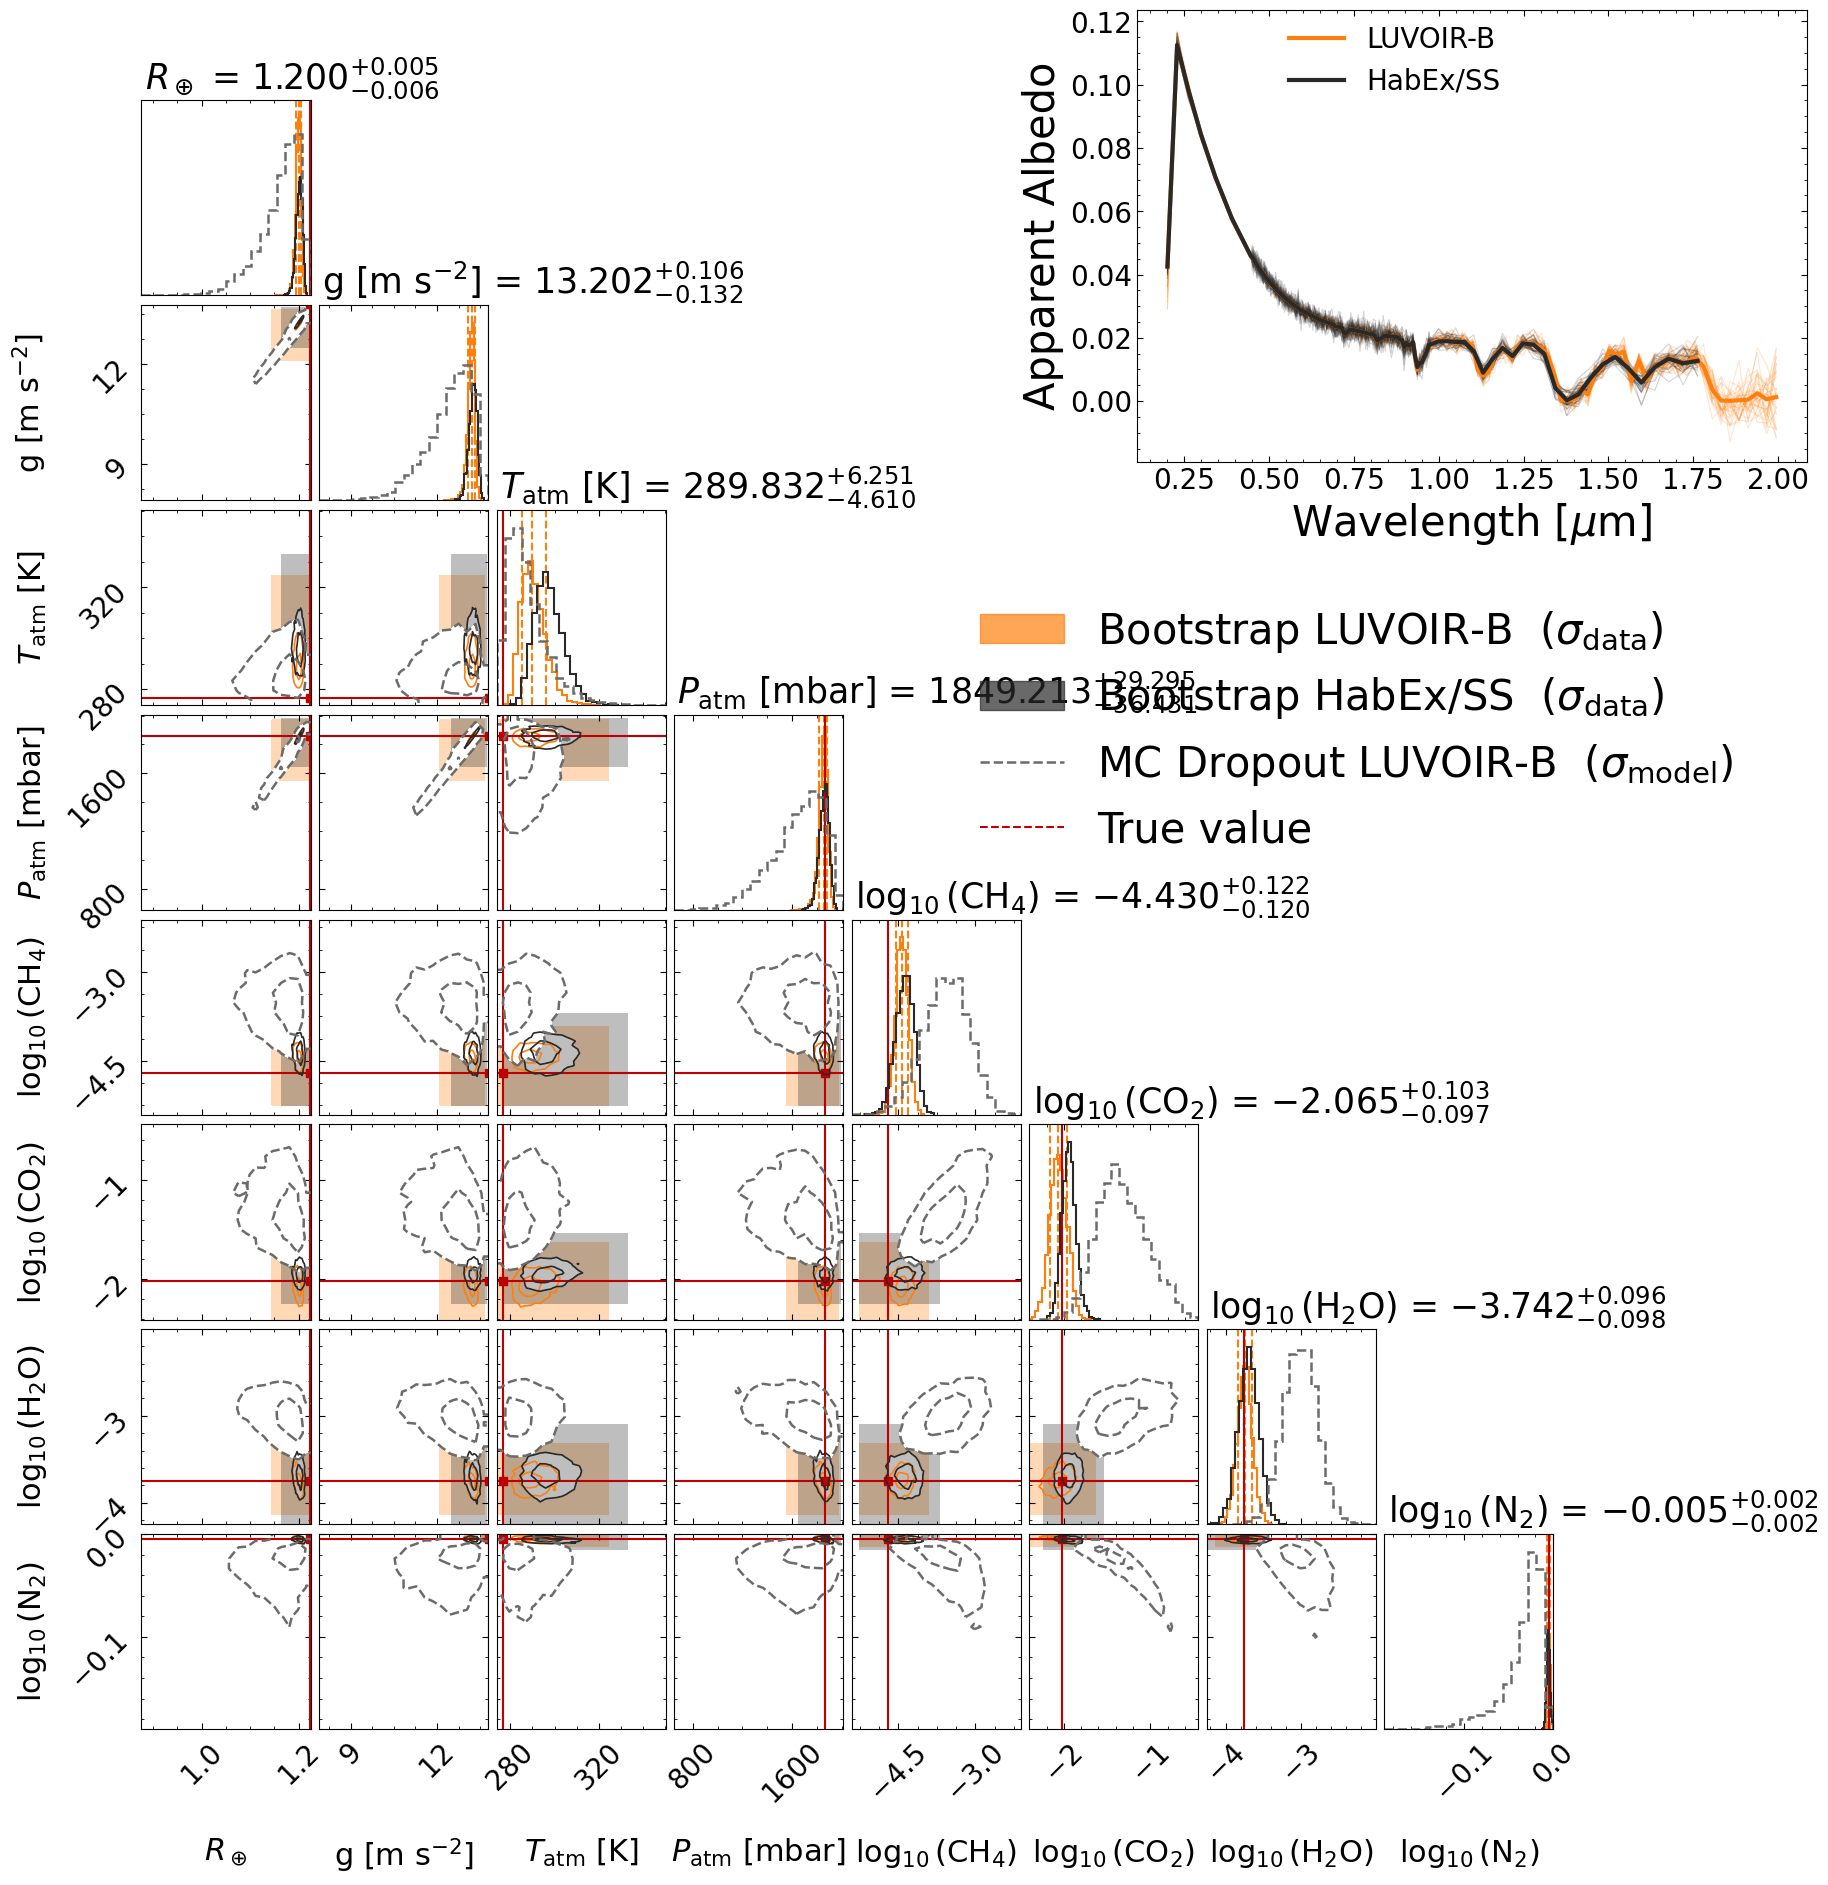

In [27]:
modern_mask = lab_LU["Earth_type"] == "archean"
modern_idx = np.where(modern_mask)[0]

SAMPLE_IDX = None
for candidate in modern_idx:
    best_n_O2 = norm_stats["outputs"]["O2"]["best_n"]
    best_n_O3 = norm_stats["outputs"]["O3"]["best_n"]
    o2_mr = float(lab_LU["O2"][candidate]) ** best_n_O2
    o3_mr = float(lab_LU["O3"][candidate]) ** best_n_O3
    if o2_mr > 1e-6 and o3_mr > 1e-10:
        SAMPLE_IDX = int(candidate)
        break

if SAMPLE_IDX is None:
    SAMPLE_IDX = int(modern_idx[0])
    print(f"Warning: no O2/O3-rich sample found, using idx={SAMPLE_IDX}")
else:
    era = lab_LU["Earth_type"][SAMPLE_IDX]
    print(f"Selected sample: #{SAMPLE_IDX}  (era={era})")
    for name in _PHYS_NAMES:
        val = _denorm_physical(float(lab_LU[name][SAMPLE_IDX]), name)
        print(f"  {name}: {val:.3f}")
    for name in _CHEM_MAIN + _CHEM_OTHER:
        best_n = norm_stats["outputs"][name]["best_n"]
        mr = float(lab_LU[name][SAMPLE_IDX]) ** best_n
        print(f"  {name}: log10 = {np.log10(mr):.2f}")

era = lab_LU["Earth_type"][SAMPLE_IDX]
fig_corner = plot_corner_bootstrap(
    SAMPLE_IDX,
    alb_LU,
    noi_LU,
    lab_LU,
    alb_HB,
    noi_HB,
    lab_HB,
    model_LUVOIR,
    model_HABEX,
    B=B_CORNER,
    N_MC=N_MC_CORNER,
    exclude_O2O3=(era == "archean"),
    save_path="../images/cornerplot_bootstrap_archean.pdf",
    color_bootstrap_lu="tab:orange",
)

# Save Results

In [28]:
os.makedirs("../data/bootstrap", exist_ok=True)

for tel, tel_key in [("LUVOIR", "luvoir"), ("HABEX", "habex")]:
    for scale in SNR_SCALES:
        result = snr_results[tel][scale]
        save_path = f"../data/bootstrap/bootstrap_{tel_key}_{scale:.1f}x.npy"
        np.save(save_path, result, allow_pickle=True)
        print(f"Saved {save_path}")

np.save("../data/bootstrap/mc_dropout_luvoir.npy", mc_LU, allow_pickle=True)
np.save("../data/bootstrap/mc_dropout_habex.npy", mc_HB, allow_pickle=True)
print("Saved MC Dropout results.")

combined = {
    "luvoir": {
        "sigma_model": std_model_LU,  # (N, 10)
        "sigma_data": std_data_LU,  # (N, 10)
        "sigma_total": total_std_LU,  # (N, 10)
        "earth_type": lab_LU["Earth_type"],
        "param_labels": PARAM_LABELS,
    },
    "habex": {
        "sigma_model": std_model_HB,
        "sigma_data": std_data_HB,
        "sigma_total": total_std_HB,
        "earth_type": lab_HB["Earth_type"],
        "param_labels": PARAM_LABELS,
    },
}
np.save("../data/bootstrap/combined_uncertainty.npy", combined, allow_pickle=True)
print("Saved combined uncertainty to data/bootstrap/combined_uncertainty.npy")

Saved ../data/bootstrap/bootstrap_luvoir_0.5x.npy
Saved ../data/bootstrap/bootstrap_luvoir_1.0x.npy
Saved ../data/bootstrap/bootstrap_luvoir_2.0x.npy
Saved ../data/bootstrap/bootstrap_luvoir_4.0x.npy
Saved ../data/bootstrap/bootstrap_habex_0.5x.npy
Saved ../data/bootstrap/bootstrap_habex_1.0x.npy
Saved ../data/bootstrap/bootstrap_habex_2.0x.npy
Saved ../data/bootstrap/bootstrap_habex_4.0x.npy
Saved MC Dropout results.
Saved combined uncertainty to data/bootstrap/combined_uncertainty.npy
